# Intern Performance Prediction Using Machine Learning

## Introduction

Machine learning has become an essential tool for analyzing large datasets and making data-driven decisions across various domains. In internship programs, understanding the factors that influence intern performance can help organizations monitor progress, identify learning gaps, and provide timely support to interns.

This project aims to develop a machine learning model that predicts intern performance using internship-related information such as attendance, task completion, mentor interactions, and feedback scores. The project follows a complete machine learning workflow, including data understanding, data cleaning, exploratory data analysis, feature engineering, data preprocessing, model development, and model evaluation. The insights generated from this analysis can support mentors in making informed decisions and improving internship outcomes.

## Problem Statement

Evaluating intern performance manually can be challenging, particularly when organizations manage a large number of interns across different departments and internship tracks. Manual evaluation may be time-consuming and can make it difficult to identify interns who require additional guidance or recognition.

The objective of this project is to build a machine learning model capable of predicting intern performance based on engagement and task completion indicators, including attendance, task submissions, mentor interactions, and feedback scores. The developed model will assist mentors in monitoring intern progress and providing personalized guidance to improve overall internship performance.

## Project Objectives

The main objectives of this project are:

- Understand the internship performance dataset.
- Perform data cleaning and preprocessing.
- Explore relationships between internship-related features and intern performance.
- Prepare the dataset for machine learning.
- Develop classification models to predict intern performance.
- Evaluate model performance using appropriate evaluation metrics.
- Identify the key factors influencing intern performance.
- Generate insights that can assist mentors in supporting interns more effectively.

## Dataset Information

This project uses an internship performance dataset containing information about interns enrolled in different departments and internship tracks during 2025. The dataset includes demographic information, educational background, internship progress, attendance records, task completion, mentor interactions, feedback scores, and the final performance status of each intern.

Each record represents an individual intern, while **Performance_Status** serves as the target variable for predicting overall intern performance. The dataset is used to analyze the factors influencing intern performance and develop a machine learning model that supports data-driven decision-making.

### Dataset Overview

| Attribute | Description |
|-----------|-------------|
| **Dataset Name** | Intern Performance Dataset |
| **File Name** | `intern_performance_2025.csv` |
| **Domain** | Internship Performance Analytics |
| **Problem Type** | Multi-Class Classification |
| **Objective** | Predict intern performance based on engagement and task completion |
| **Target Variable** | Performance_Status |
| **Total Records** | 70,000 |
| **Total Features** | 20 |
| **Data Format** | CSV |

### Dataset Features

| Feature | Description |
|---------|-------------|
| **Intern_ID** | Unique identifier assigned to each intern. |
| **Intern_Name** | Name of the intern. |
| **Gender** | Gender of the intern. |
| **Age** | Age of the intern in years. |
| **City** | City where the intern resides. |
| **Education** | Highest educational qualification of the intern. |
| **Institute** | Educational institute attended by the intern. |
| **Department** | Main internship department in which the intern is enrolled. |
| **Internship_Track** | Specific specialization or learning track within the selected department. |
| **Mentor_ID** | Unique identifier assigned to the mentor. |
| **Mentor_Name** | Name of the assigned mentor. |
| **Enrollment_Date** | Date on which the intern joined the internship. |
| **Internship_Duration_Weeks** | Total duration of the internship in weeks. |
| **Weeks_Completed** | Number of internship weeks completed by the intern. |
| **Attendance_Percentage** | Attendance percentage maintained during the internship. |
| **Tasks_Assigned** | Total number of tasks assigned to the intern. |
| **Tasks_Submitted** | Total number of tasks submitted by the intern. |
| **Mentor_Interactions** | Number of interactions between the intern and mentor. |
| **Feedback_Score** | Overall feedback score assigned by the mentor. |
| **Performance_Status** | Final performance category of the intern (**Target Variable**). |

## Import Required Libraries

The following libraries are imported to support data manipulation, data visualization, data preprocessing, machine learning, and model evaluation throughout the project.

In [5]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

## Load Dataset

The internship performance dataset is loaded into a Pandas DataFrame for analysis. During this step, the **Enrollment_Date** column is converted to the `datetime` data type to enable date-based analysis, and a working copy of the dataset is created for data cleaning, preprocessing, and feature engineering while preserving the original data.

In [2]:
# Load the dataset
df = pd.read_csv("../dataset/raw/intern_performance_2025.csv")

# Convert Enrollment_Date to datetime format
df["Enrollment_Date"] = pd.to_datetime(df["Enrollment_Date"])

# Create a copy of the original dataset
df_clean = df.copy()

## Dataset Preview

The first five records of the dataset are displayed to verify that the dataset has been loaded successfully and to gain an initial understanding of its structure.

In [3]:
# Display the first five rows of the dataset
df.head()

,Intern_ID,Intern_Name,Gender,Age,City,Education,Institute,Department,Internship_Track,Mentor_ID,Mentor_Name,Enrollment_Date,Internship_Duration_Weeks,Weeks_Completed,Attendance_Percentage,Tasks_Assigned,Tasks_Submitted,Mentor_Interactions,Feedback_Score,Performance_Status
0,INT00001,Kamran Nawaz,Male,20,Rahim Yar Khan,BS Software Engineering,Iqra University,App Development,Flutter,MTR017,Hassan Ali,2025-10-30,8,8,85,8,7,9,3.6,Good
1,INT00002,Ayesha Awan,Female,22,Sargodha,BS Computer Science,Government College University Faisalabad,Graphic Design,Photoshop,MTR013,Komal Raza,2025-06-22,8,8,61,8,7,4,3.3,Good
2,INT00003,Hammad Javed,Male,22,Hyderabad,BS Artificial Intelligence,Virtual University of Pakistan,Graphic Design,Figma,MTR016,Laiba Ahmed,2025-02-05,8,8,61,8,6,4,2.7,Average
3,INT00004,Ahsan Rasheed,Male,21,Sialkot,BS Information Technology,FAST National University,Backend Development,Node.js,MTR002,Ahmed Raza,2025-08-25,8,8,63,8,5,3,2.8,Average
4,INT00005,Noor Fatima Waheed,Female,26,Gujranwala,BS Computer Science,Iqra University,Frontend Development,HTML CSS JS,MTR006,Fatima Noor,2025-03-15,8,8,78,8,8,9,3.9,Excellent


## Dataset Summary

This section provides an overview of the dataset structure and verifies its quality before proceeding to data cleaning and exploratory data analysis.

### Dataset Information

In [4]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Intern_ID                  70000 non-null  str           
 1   Intern_Name                70000 non-null  str           
 2   Gender                     70000 non-null  str           
 3   Age                        70000 non-null  int64         
 4   City                       70000 non-null  str           
 5   Education                  70000 non-null  str           
 6   Institute                  70000 non-null  str           
 7   Department                 70000 non-null  str           
 8   Internship_Track           70000 non-null  str           
 9   Mentor_ID                  70000 non-null  str           
 10  Mentor_Name                70000 non-null  str           
 11  Enrollment_Date            70000 non-null  datetime64[us]
 12  Internship_Dura

**Observation**

The dataset consists of **70,000 records** and **20 features**, including both numerical and categorical variables. All columns contain **70,000 non-null values**, indicating that there are no missing values in the dataset. The dataset occupies approximately **19.9 MB** of memory, making it suitable for efficient analysis and machine learning.

## Data Cleaning

Data cleaning is an essential step in the machine learning workflow that ensures the dataset is accurate, consistent, and suitable for analysis. In this section, the dataset is examined for potential data quality issues, and only the necessary cleaning procedures are applied before moving to exploratory data analysis.

### Verify Data Quality

The dataset is verified for common data quality issues, including missing values and duplicate records. This step confirms whether any additional cleaning is required before proceeding with the analysis.

In [5]:
# Check missing values
print("Missing Values:", df.isnull().sum().sum())

# Check duplicate records
print("Duplicate Records:", df.duplicated().sum())

Missing Values: 0
Duplicate Records: 0


**Observation**

The dataset contains no missing values and no duplicate records. Therefore, no additional data cleaning was required, and the dataset is ready for further validation.

### Validate Numerical Features

The numerical features are reviewed to verify that their values fall within reasonable and expected ranges. This step helps identify any invalid or inconsistent values that may affect the analysis or machine learning models.

In [6]:
# Summary statistics for numerical features
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,70000.0,21.651143,17.0,19.0,21.0,24.0,32.0,2.812952
Enrollment_Date,70000,2025-06-04 02:30:27.565714,2025-01-01 00:00:00,2025-03-19 00:00:00,2025-06-04 00:00:00,2025-08-21 00:00:00,2025-11-05 00:00:00,NaN
Internship_Duration_Weeks,70000.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0
Weeks_Completed,70000.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0
Attendance_Percentage,70000.0,82.378486,40.0,76.0,85.0,92.0,100.0,12.449414
Tasks_Assigned,70000.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0
Tasks_Submitted,70000.0,7.055257,3.0,7.0,7.0,8.0,8.0,1.07059
Mentor_Interactions,70000.0,8.310471,2.0,6.0,8.0,10.0,15.0,3.250231
Feedback_Score,70000.0,3.809614,1.2,3.4,3.9,4.4,5.0,0.733558


**Observation**

The summary statistics indicate that the numerical features contain valid and reasonable values. The **Age** ranges from **17 to 32 years**, **Attendance_Percentage** ranges from **40% to 100%**, **Tasks_Submitted** ranges from **3 to 8**, **Mentor_Interactions** ranges from **2 to 15**, and **Feedback_Score** ranges from **1.2 to 5.0**. No obvious invalid or inconsistent numerical values were identified during the initial inspection.

### Check for Outliers

The numerical features are examined for potential outliers that may influence statistical analysis and machine learning model performance. Boxplots are used to visually identify unusual observations and determine whether any outlier treatment is required.

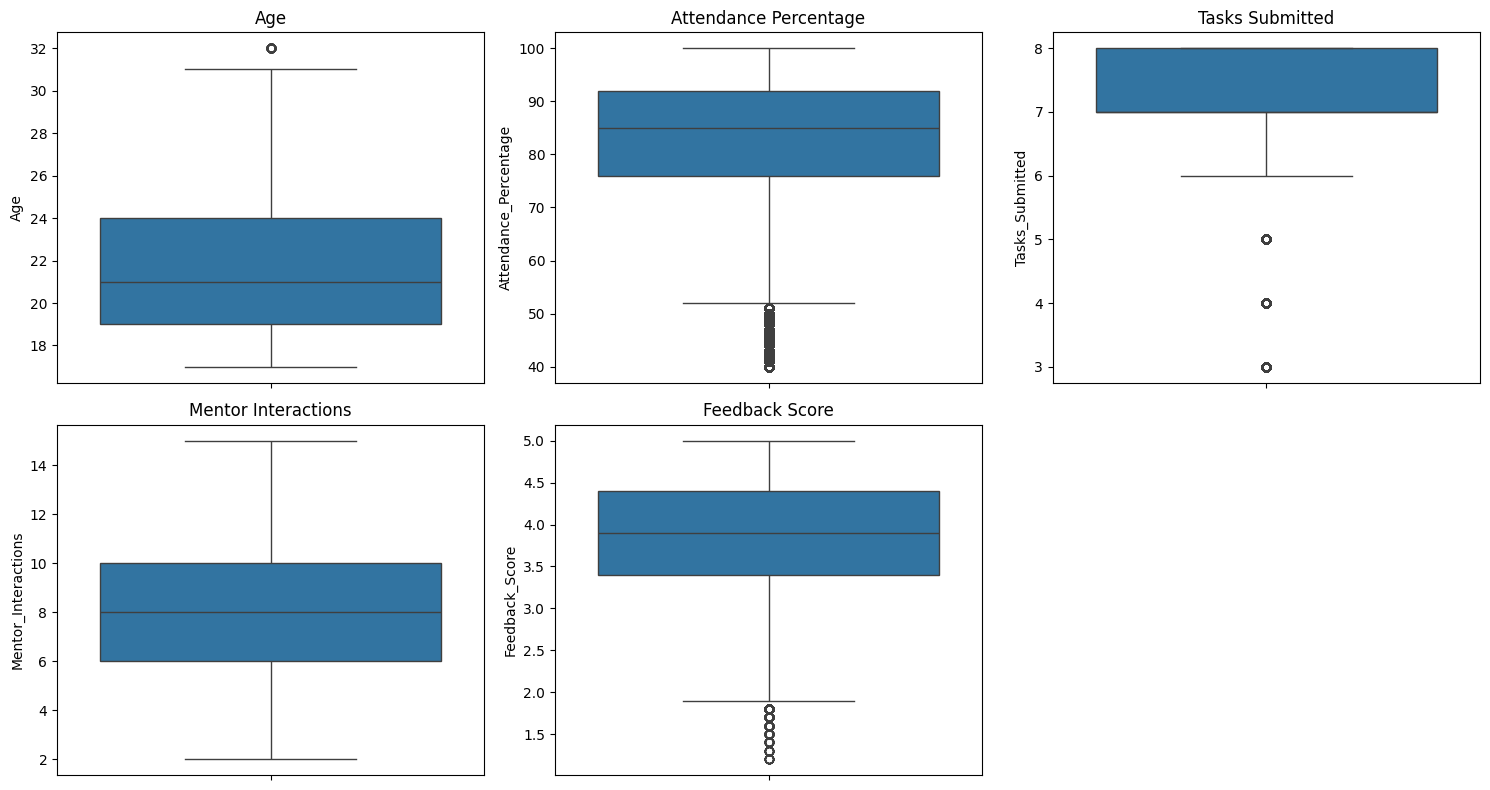

In [7]:
# Select numerical features for outlier detection
numerical_features = [
    "Age",
    "Attendance_Percentage",
    "Tasks_Submitted",
    "Mentor_Interactions",
    "Feedback_Score"
]

# Create boxplots
plt.figure(figsize=(15, 8))

for index, column in enumerate(numerical_features, 1):
    plt.subplot(2, 3, index)
    sns.boxplot(y=df[column])
    plt.title(column.replace("_", " "))

plt.tight_layout()

# Save figure
# plt.savefig("../outputs/figures/01_outlier_boxplots.png",
#             dpi=300,
#             bbox_inches="tight")

plt.show()

**Observation:**

The boxplots indicate that a few numerical features contain outliers. **Attendance_Percentage**, **Tasks_Submitted**, and **Feedback_Score** show several lower-end outliers, while **Age** contains only a few upper-end outliers. **Mentor_Interactions** does not exhibit any significant outliers. These observations appear to represent valid variations in intern performance rather than data entry errors. Therefore, no outlier treatment was applied, and the dataset was retained in its original form for further analysis.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the internship performance dataset through statistical summaries and visualizations. This process helps identify data distributions, feature relationships, and meaningful patterns that support better decision-making during model development.

### Target Variable Distribution

The distribution of the target variable is analyzed to understand how internship performance is distributed across different performance categories. This analysis helps identify whether the dataset is balanced before training machine learning models.

In [8]:
# Display target variable counts
df["Performance_Status"].value_counts()

Performance_Status
Excellent    30907
Good         27075
Average      10229
Poor          1789
Name: count, dtype: int64

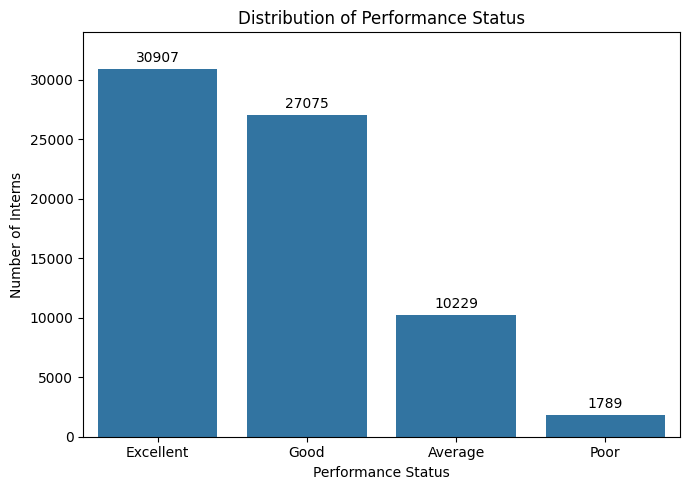

In [9]:
# Plot target variable distribution
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Performance_Status",
    order=df["Performance_Status"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase y-axis limit for data labels
plt.ylim(0, df["Performance_Status"].value_counts().max() * 1.10)

plt.title("Distribution of Performance Status")
plt.xlabel("Performance Status")
plt.ylabel("Number of Interns")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/02_Performance_Status_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The target variable shows an imbalanced distribution across the four performance categories. The **Excellent** category contains the highest number of interns (30,907), followed by **Good** (27,075). In comparison, **Average** (10,229) and especially **Poor** (1,789) contain substantially fewer records. This indicates that most interns achieved higher performance levels, while only a small proportion were classified as poor performers. The observed class imbalance should be considered during the model development and evaluation stages to ensure reliable prediction performance across all classes.

### Categorical Feature Analysis

The categorical features are analyzed to understand the distribution of interns across different categories. This analysis helps identify the composition of the dataset and highlights the representation of each categorical variable before model development.

#### Gender Distribution

The distribution of interns by gender is analyzed to understand the demographic composition of the internship dataset. This analysis provides an overview of gender representation across all internship records.

In [10]:
df["Gender"].value_counts()

Gender
Male      44494
Female    25506
Name: count, dtype: int64

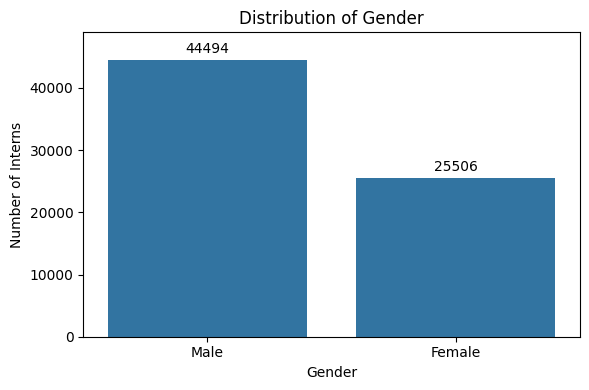

In [11]:
# Plot gender distribution
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Gender",
    order=df["Gender"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase y-axis limit for data labels
plt.ylim(0, df["Gender"].value_counts().max() * 1.10)

plt.title("Distribution of Gender")

plt.xlabel("Gender")
plt.ylabel("Number of Interns")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/03_Gender_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The dataset contains a higher proportion of **male interns (44,494)** compared to **female interns (25,506)**. This indicates that male interns are more strongly represented in the dataset. Although both gender categories contain a substantial number of records, the distribution is not perfectly balanced, which should be considered when interpreting gender-related analyses and model results.

#### Department Distribution

The distribution of interns across different departments is analyzed to understand the representation of each department within the internship program. This analysis highlights the participation of interns in various functional areas.

In [12]:
df["Department"].value_counts()

Department
Frontend Development    16849
Backend Development     15435
App Development         11388
Graphic Design          10451
Other Internships       10421
Chatbot Development      5456
Name: count, dtype: int64

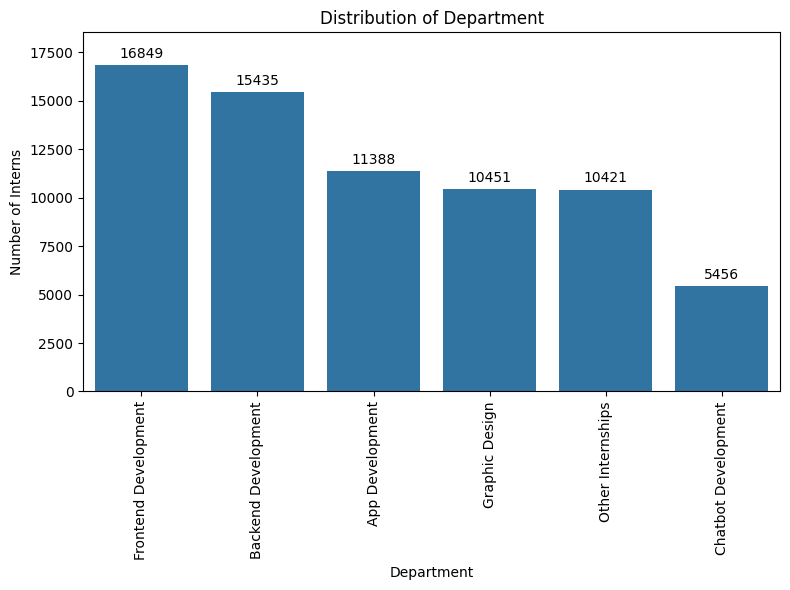

In [13]:
# Plot department distribution
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase y-axis limit for data labels
plt.ylim(0, df["Department"].value_counts().max() * 1.10)

plt.title("Distribution of Department")

plt.xlabel("Department")
plt.ylabel("Number of Interns")

plt.xticks(rotation=90)

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/04_Department_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The department distribution shows that **Frontend Development (16,849)** has the highest number of interns, followed by **Backend Development (15,435)**. **App Development (11,388)**, **Graphic Design (10,451)**, and **Other Internships (10,421)** have relatively similar levels of participation. In contrast, **Chatbot Development (5,456)** has the lowest representation among all departments. Overall, the dataset includes interns from multiple departments, although the representation varies across different internship areas.

#### Internship Track Distribution

The distribution of interns across different internship tracks is analyzed to understand the participation of interns in each specialization. This analysis provides an overview of the popularity and representation of various internship tracks within the dataset.

In [14]:
df["Internship_Track"].value_counts()

Internship_Track
PHP                 4704
Flutter             4504
React               3992
Node.js             3815
MERN Stack          3809
Photoshop           3728
React Native        3456
HTML CSS JS         3360
Figma               3081
WordPress           3038
Illustrator         2600
Android             2306
Generative AI       2207
Next.js             2060
Data Science        2045
Data Analytics      1878
MEAN Stack          1817
Angular             1724
Social Media        1594
Machine Learning    1469
Django              1356
.NET Core           1319
Web 3.0             1290
Cyber Security      1266
RASA                1123
Swift               1122
Video Editing       1100
Dialogflow          1075
Cloud Computing     1069
Autodesk Maya       1042
Salesforce CRM       527
Alexa Skill          524
Name: count, dtype: int64

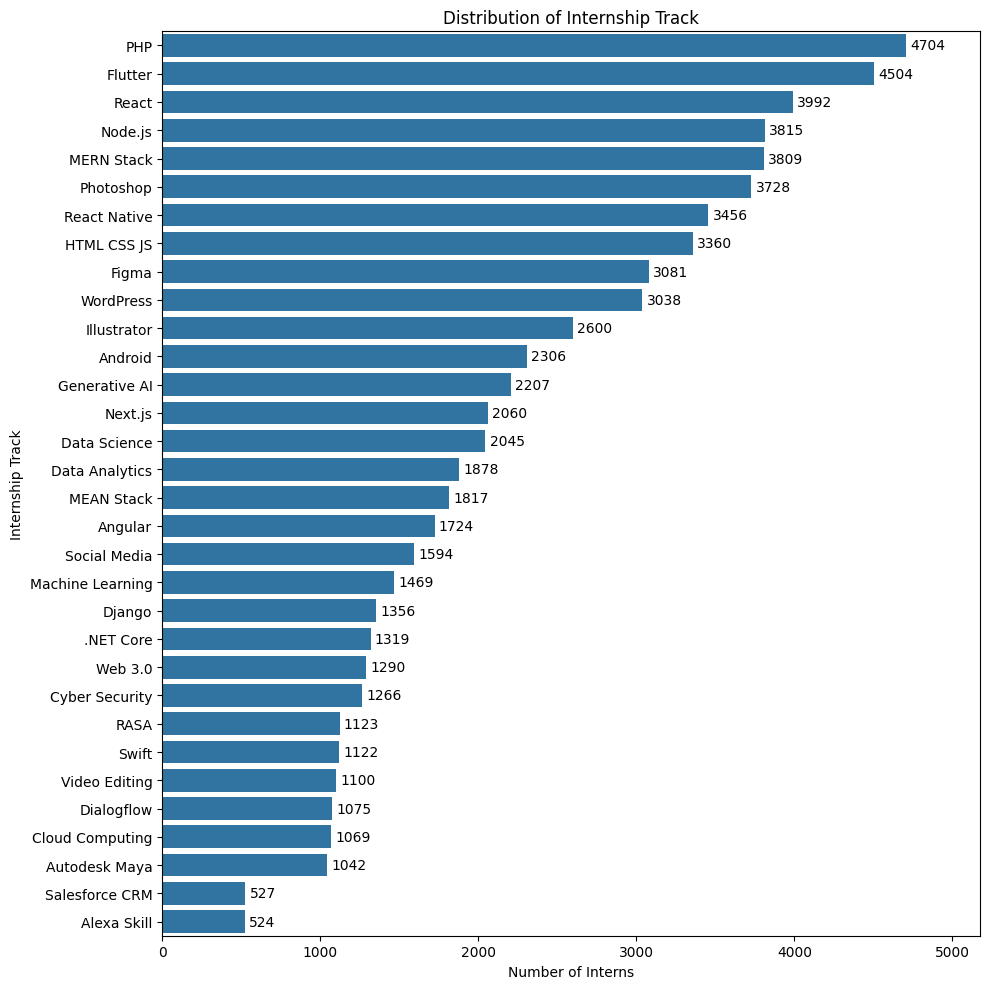

In [15]:
# Plot internship track distribution
plt.figure(figsize=(10, 10))

ax = sns.countplot(
    data=df,
    y="Internship_Track",
    order=df["Internship_Track"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, df["Internship_Track"].value_counts().max() * 1.10)

plt.title("Distribution of Internship Track")

plt.xlabel("Number of Interns")
plt.ylabel("Internship Track")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/05_Internship_Track_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The internship track distribution indicates varying levels of participation across different technical specializations. **PHP (4,704)** has the highest number of interns, followed by **Flutter (4,504)**, **React (3,992)**, **Node.js (3,815)**, and **MERN Stack (3,809)**. Mid-level participation is observed in tracks such as **React Native**, **HTML CSS JS**, **Figma**, and **WordPress**, whereas specialized tracks including **Salesforce CRM (527)** and **Alexa Skill (524)** have the lowest number of interns. Overall, the dataset represents a wide range of internship tracks, although participation is uneven across different specializations.

#### Education Level Distribution

The distribution of interns by education level is analyzed to understand the academic background of participants in the internship program. This analysis provides insights into the representation of different educational qualifications within the dataset.

In [16]:
df["Education"].value_counts()

Education
BS Computer Science                      12411
BS Software Engineering                   8368
BS Information Technology                 8227
ICS                                       6784
FSC (Pre-Engineering)                     4208
BS Data Science                           4121
BS Artificial Intelligence                3523
BS Data Analytics                         3497
DAE (Computer Information Technology)     3485
BS Cyber Security                         2841
FSC (Pre-Medical)                         2067
BS Computer Engineering                   2036
DAE (Electrical Technology)               1466
MCS                                       1425
DAE (Mechanical Technology)               1412
ICOM                                      1392
BBA                                       1348
MBA                                        716
MS Computer Science                        673
Name: count, dtype: int64

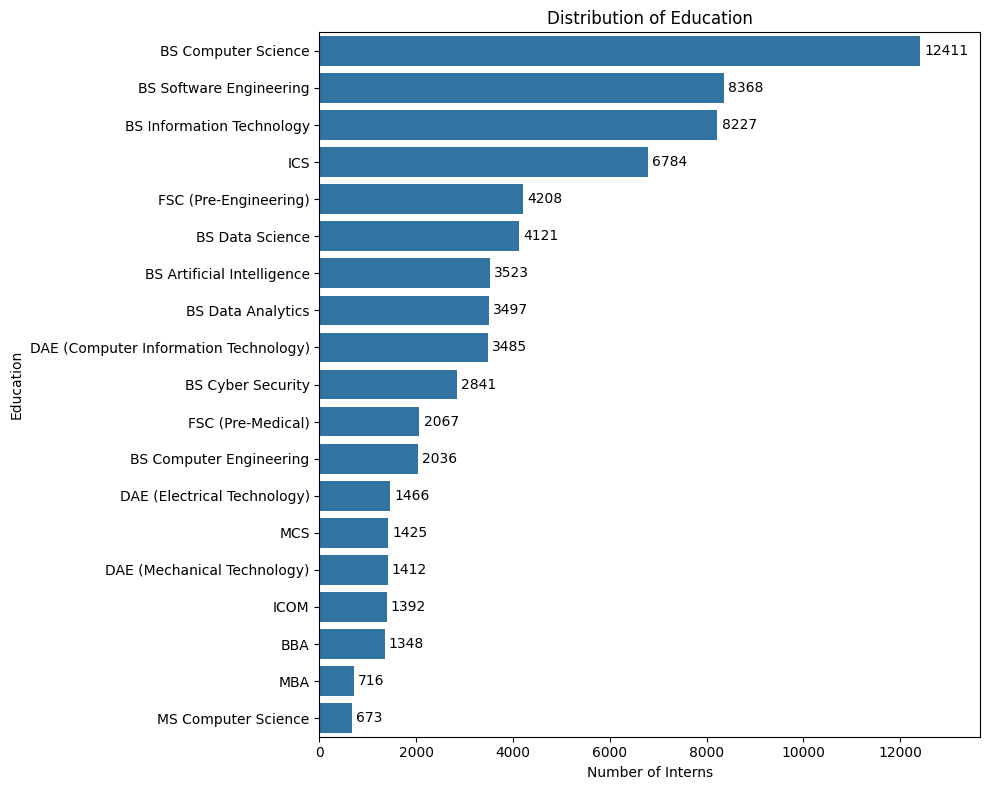

In [17]:
# Plot education distribution
plt.figure(figsize=(10, 8))

ax = sns.countplot(
    data=df,
    y="Education",
    order=df["Education"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, df["Education"].value_counts().max() * 1.10)

plt.title("Distribution of Education")

plt.xlabel("Number of Interns")
plt.ylabel("Education")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/06_Education_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The education distribution indicates that **BS Computer Science (12,411)** has the highest number of interns, followed by **BS Software Engineering (8,368)**, **BS Information Technology (8,227)**, and **ICS (6,784)**. Moderate participation is observed in programs such as **FSC (Pre-Engineering)**, **BS Data Science**, **BS Artificial Intelligence**, and **BS Data Analytics**. In contrast, postgraduate qualifications including **MBA (716)** and **MS Computer Science (673)** have the lowest representation. Overall, the dataset includes interns from a diverse range of educational backgrounds, with undergraduate computing-related programs contributing the largest share of participants.

#### City Distribution

The distribution of interns across different cities is analyzed to understand the geographical representation of participants in the internship program. This analysis highlights the contribution of different cities to the overall internship population.

In [18]:
df["City"].value_counts()

City
Karachi            11186
Lahore              9274
Islamabad           4885
Faisalabad          4413
Rawalpindi          4358
Multan              3109
Peshawar            2965
Sialkot             1913
Quetta              1876
Gujranwala          1868
Hyderabad           1819
Mardan              1316
Sheikhupura         1282
Sahiwal             1231
Sargodha            1219
Bahawalpur          1215
Rahim Yar Khan      1205
Gujrat              1180
Larkana              681
Gwadar               664
Muzaffarabad         650
Jacobabad            646
Nawabshah            644
Kohat                643
Sukkur               641
Chiniot              641
Okara                641
Wah Cantt            638
Mingora              631
Pakpattan            629
Turbat               622
Nowshera             617
Khushab              606
Jhang                603
Abbottabad           603
Dera Ghazi Khan      601
Vehari               592
Mirpur Khas          579
Bannu                566
Kasur               

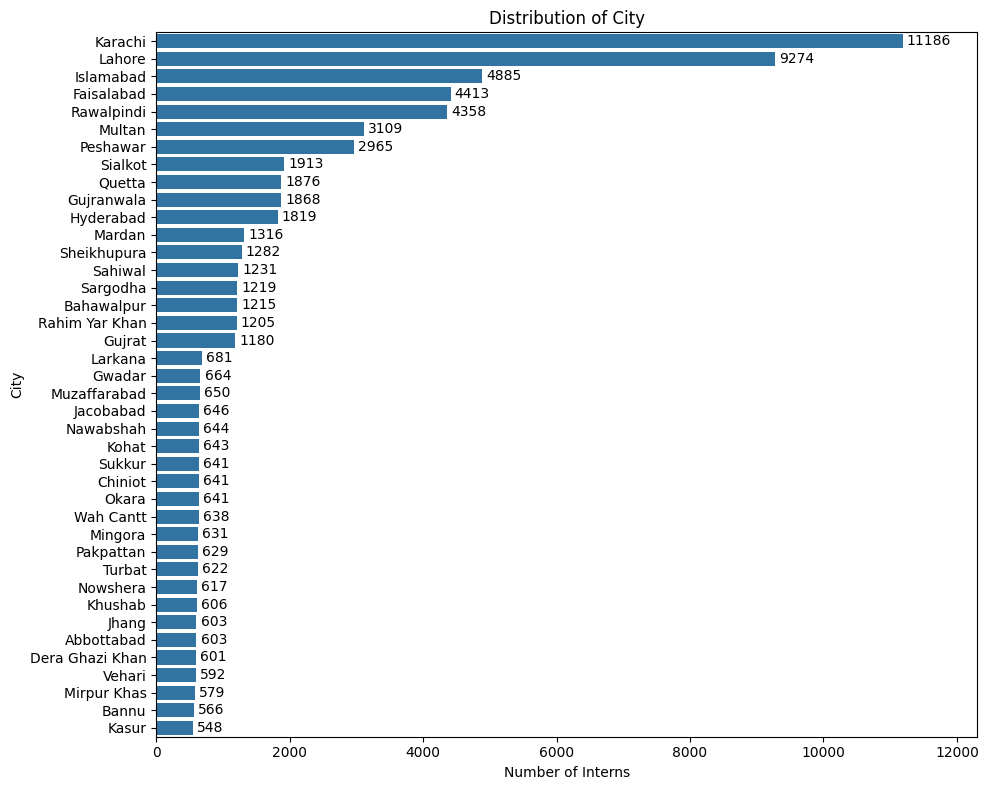

In [19]:
# Plot city distribution
plt.figure(figsize=(10, 8))

ax = sns.countplot(
    data=df,
    y="City",
    order=df["City"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, df["City"].value_counts().max() * 1.10)

plt.title("Distribution of City")

plt.xlabel("Number of Interns")
plt.ylabel("City")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/07_City_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

The city distribution shows that **Karachi (11,186)** has the highest number of interns, followed by **Lahore (9,274)**. Other major contributors include **Islamabad (4,885)**, **Faisalabad (4,413)**, **Rawalpindi (4,358)**, **Multan (3,109)**, and **Peshawar (2,965)**. The remaining cities each contribute comparatively smaller numbers of interns, indicating a broad geographical representation across Pakistan. Overall, the internship dataset includes participants from a diverse range of cities, with higher participation concentrated in major urban centers.

#### Institute Distribution

The distribution of interns across different educational institutes is analyzed to understand the institutional representation within the internship program. This analysis provides an overview of participation from various institutes.

In [20]:
df["Institute"].value_counts()

Institute
University of Central Punjab                      3345
Government College University Faisalabad          3332
COMSATS University Islamabad                      3327
Bahria University                                 3321
FAST National University                          3312
University of Education                           3311
National University of Sciences and Technology    3303
University of Engineering and Technology          3287
Superior University                               3274
Riphah International University                   3238
University of the Punjab                          3237
Virtual University of Pakistan                    3234
Air University                                    3234
University of Management and Technology           3234
Iqra University                                   3197
Government College Lahore                         1501
Punjab Group of Colleges                          1487
Government College Faisalabad                     1465


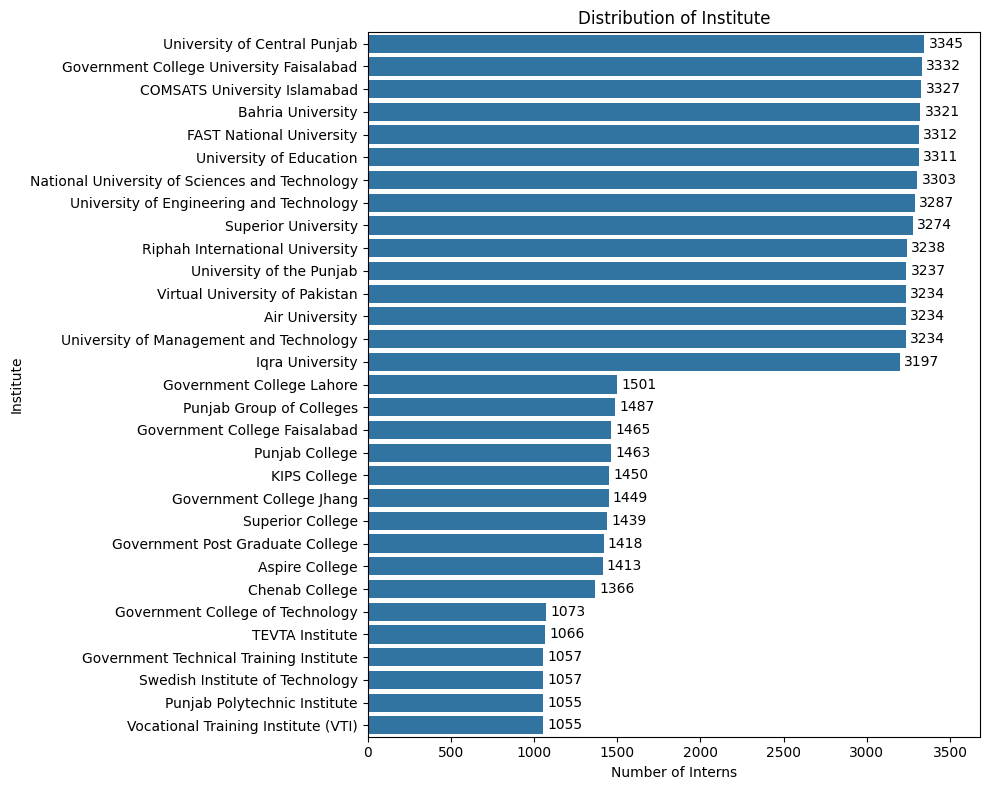

In [21]:
# Plot institute distribution
plt.figure(figsize=(10, 8))

ax = sns.countplot(
    data=df,
    y="Institute",
    order=df["Institute"].value_counts().index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, df["Institute"].value_counts().max() * 1.10)

plt.title("Distribution of Institute")

plt.xlabel("Number of Interns")
plt.ylabel("Institute")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/08_Institute_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

The institute distribution shows a relatively balanced representation across multiple educational institutions. **University of Central Punjab (3,345)** has the highest number of interns, closely followed by **Government College University Faisalabad (3,332)**, **COMSATS University Islamabad (3,327)**, **Bahria University (3,321)**, **FAST National University (3,312)**, and **University of Education (3,311)**. Several other universities also contribute a comparable number of interns, whereas colleges and technical institutes generally have lower participation. Overall, the dataset includes interns from a diverse range of universities, colleges, and technical institutes, providing broad institutional representation.

### Numerical Feature Distribution

The distribution of numerical features is analyzed to understand their underlying patterns, central tendencies, and variability. Histograms with kernel density estimation (KDE) are used to visualize the distribution of each numerical variable before model development.

#### Age Distribution

The distribution of intern age is analyzed to examine the age composition of participants and identify the overall pattern of age values within the dataset.

In [22]:
# Display age distribution
df["Age"].value_counts().sort_index()

Age
17     3632
18     4733
19    10379
20    10503
21     6889
22     6973
23     7161
24     6211
25     6166
26     5835
27      354
28      353
29      326
30      336
31       65
32       84
Name: count, dtype: int64

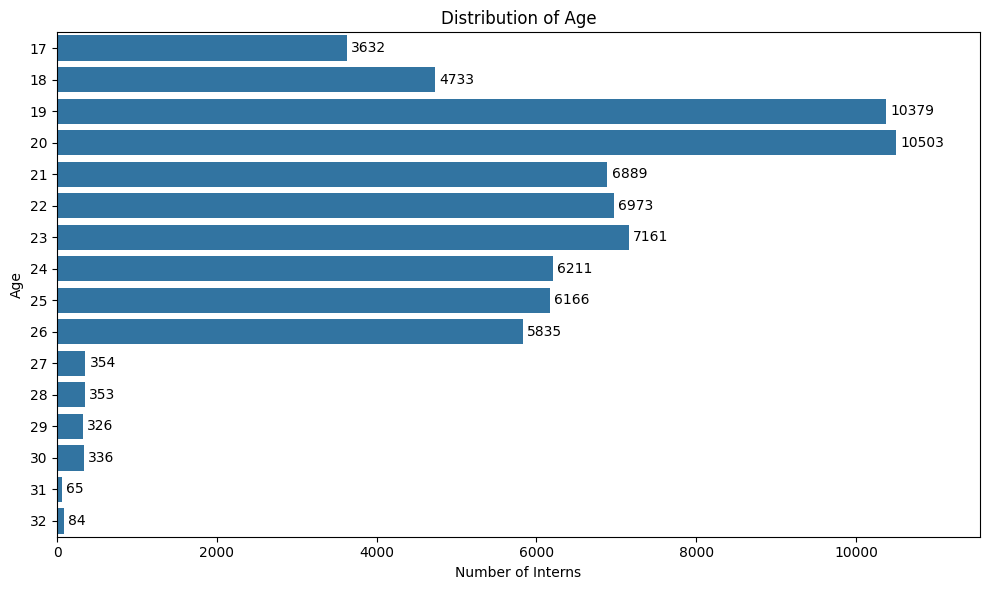

In [23]:
# Plot age distribution
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    y="Age"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, df["Age"].value_counts().max() * 1.10)

plt.title("Distribution of Age")

plt.ylabel("Age")
plt.xlabel("Number of Interns")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/09_Age_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The age distribution indicates that most interns are between **19 and 26 years** of age. The highest number of interns are **19 years old (10,379)**, closely followed by **20 years old (10,503)**. Participation remains relatively high for ages **21 to 26**, while the number of interns declines substantially for ages **27 years and above**. Overall, the dataset is dominated by young adults, reflecting the typical age range of students and recent graduates participating in internship programs.

#### Attendance Percentage Distribution

The distribution of attendance percentage is analyzed to understand the attendance patterns of interns throughout the internship program. This analysis helps identify the overall distribution and concentration of attendance values within the dataset.

In [24]:
# Display attendance percentage summary
df["Attendance_Percentage"].describe()

count    70000.000000
mean        82.378486
std         12.449414
min         40.000000
25%         76.000000
50%         85.000000
75%         92.000000
max        100.000000
Name: Attendance_Percentage, dtype: float64

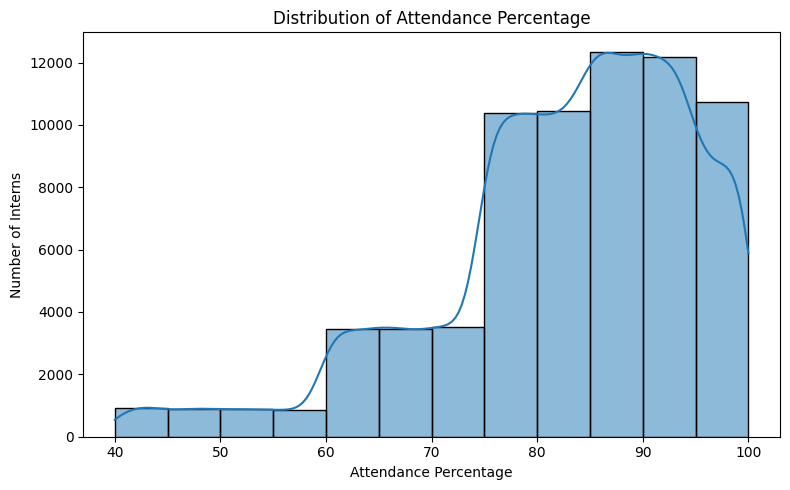

In [25]:
# Plot attendance percentage distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Attendance_Percentage",
    bins=12,
    kde=True
)

plt.title("Distribution of Attendance Percentage")

plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Interns")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/10_Attendance_Percentage_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The attendance percentage distribution indicates that most interns have **high attendance levels**, with the majority of records concentrated between **75% and 100%**. The highest concentration of interns falls within the **85% to 95%** attendance range, while comparatively fewer interns have attendance below **70%**. Overall, the distribution is slightly skewed toward higher attendance percentages, indicating that most interns maintained consistently good attendance throughout the internship program.

#### Tasks Submitted Distribution

The distribution of submitted tasks is analyzed to understand the level of task completion among interns during the internship program. This analysis provides an overview of how many tasks were completed by participants.

In [26]:
# Display tasks submitted distribution
df["Tasks_Submitted"].value_counts().sort_index()

Tasks_Submitted
3      890
4      835
5     4428
6    11094
7    22870
8    29883
Name: count, dtype: int64

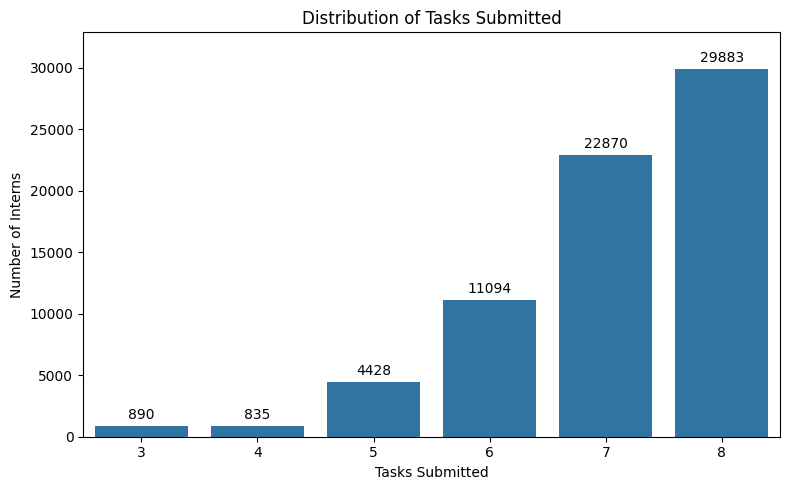

In [27]:
# Plot tasks submitted distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Tasks_Submitted"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase y-axis limit for data labels
plt.ylim(0, df["Tasks_Submitted"].value_counts().max() * 1.10)

plt.title("Distribution of Tasks Submitted")

plt.ylabel("Number of Interns")
plt.xlabel("Tasks Submitted")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/11_Tasks_Submitted_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The distribution of submitted tasks indicates that most interns completed a high number of assigned tasks. The highest number of interns submitted **8 tasks (29,883)**, followed by **7 tasks (22,870)** and **6 tasks (11,094)**. In contrast, relatively few interns submitted **3 tasks (890)** or **4 tasks (835)**. Overall, the distribution is concentrated toward higher task completion levels, indicating that the majority of interns successfully completed most of their assigned tasks.

#### Mentor Interactions Distribution

The distribution of mentor interactions is analyzed to understand the level of communication between interns and their mentors throughout the internship program. This analysis provides an overview of how frequently interns interacted with their assigned mentors.

In [28]:
# Display mentor interactions distribution
df["Mentor_Interactions"].value_counts().sort_index()

Mentor_Interactions
2     2455
3     2259
4     2326
5     7837
6     7855
7     7903
8     6729
9     6869
10    9366
11    3987
12    3967
13    2774
14    2825
15    2848
Name: count, dtype: int64

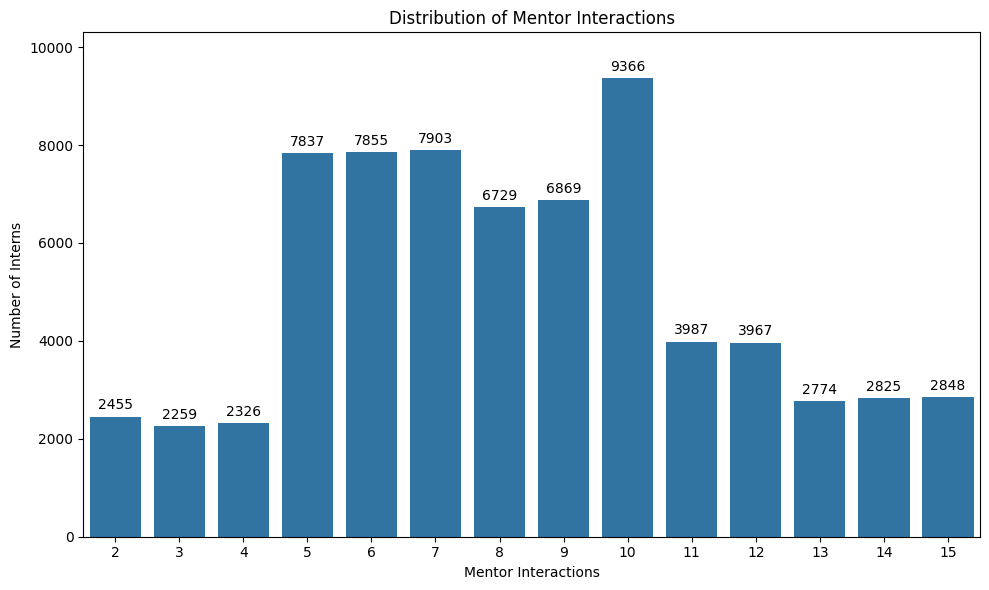

In [29]:
# Plot mentor interactions distribution
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="Mentor_Interactions"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase y-axis limit for data labels
plt.ylim(0, df["Mentor_Interactions"].value_counts().max() * 1.10)

plt.title("Distribution of Mentor Interactions")

plt.xlabel("Mentor Interactions")
plt.ylabel("Number of Interns")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/12_Mentor_Interactions_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The distribution of mentor interactions indicates that most interns had **moderate to high levels of communication** with their mentors. The highest number of interns recorded **10 mentor interactions (9,366)**, followed by **7 interactions (7,903)**, **6 interactions (7,855)**, and **5 interactions (7,837)**. Lower frequencies are observed for **2–4 interactions**, while participation gradually decreases after **10 interactions**. Overall, the distribution suggests that the majority of interns maintained regular communication with their mentors throughout the internship program.

#### Feedback Score Distribution

The distribution of feedback scores is analyzed to understand the evaluation patterns of interns based on mentor assessments. This analysis provides insights into the overall distribution of feedback scores within the internship program.

In [30]:
# Display feedback score summary
df["Feedback_Score"].describe()

count    70000.000000
mean         3.809614
std          0.733558
min          1.200000
25%          3.400000
50%          3.900000
75%          4.400000
max          5.000000
Name: Feedback_Score, dtype: float64

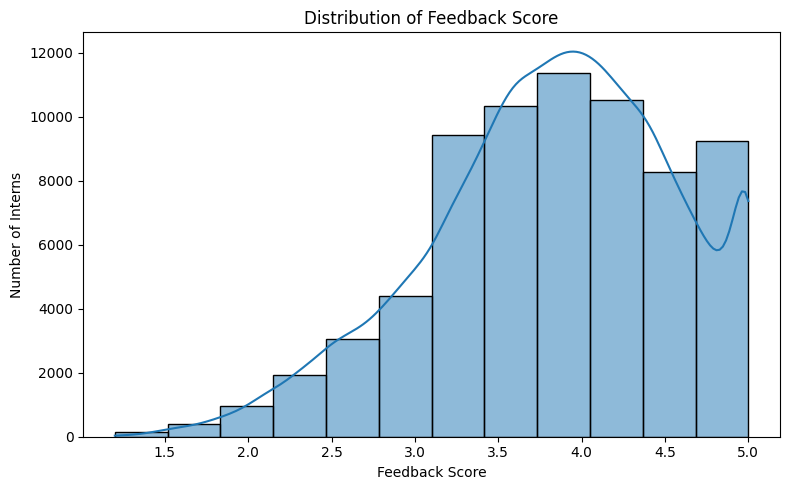

In [31]:
# Plot feedback score distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Feedback_Score",
    bins=12,
    kde=True
)

plt.title("Distribution of Feedback Score")

plt.xlabel("Feedback Score")
plt.ylabel("Number of Interns")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/13_Feedback_Score_Distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation:**

The feedback score distribution indicates that most interns received **high feedback scores**, with the majority of values concentrated between **3.5 and 4.5**. The highest concentration of feedback scores is observed around **4.0**, while comparatively fewer interns received scores below **3.0**. Overall, the distribution is skewed toward higher feedback scores, suggesting that most interns were evaluated positively during the internship program.

### Correlation Analysis

Correlation analysis is performed to measure the strength and direction of relationships among numerical features in the dataset. The Pearson correlation coefficient is used to identify positive and negative linear relationships, helping determine which features are more closely associated with one another before machine learning model development.

In [32]:
# Select numerical features
numerical_features = [
    "Age",
    "Attendance_Percentage",
    "Tasks_Submitted",
    "Mentor_Interactions",
    "Feedback_Score"
]

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

# Display correlation matrix
correlation_matrix

,Age,Attendance_Percentage,Tasks_Submitted,Mentor_Interactions,Feedback_Score
Age,1.000000,-0.002726,-0.002299,-0.002171,-0.003343
Attendance_Percentage,-0.002726,1.000000,0.747183,0.733705,0.847988
Tasks_Submitted,-0.002299,0.747183,1.000000,0.567563,0.782466
Mentor_Interactions,-0.002171,0.733705,0.567563,1.000000,0.822280
Feedback_Score,-0.003343,0.847988,0.782466,0.822280,1.000000


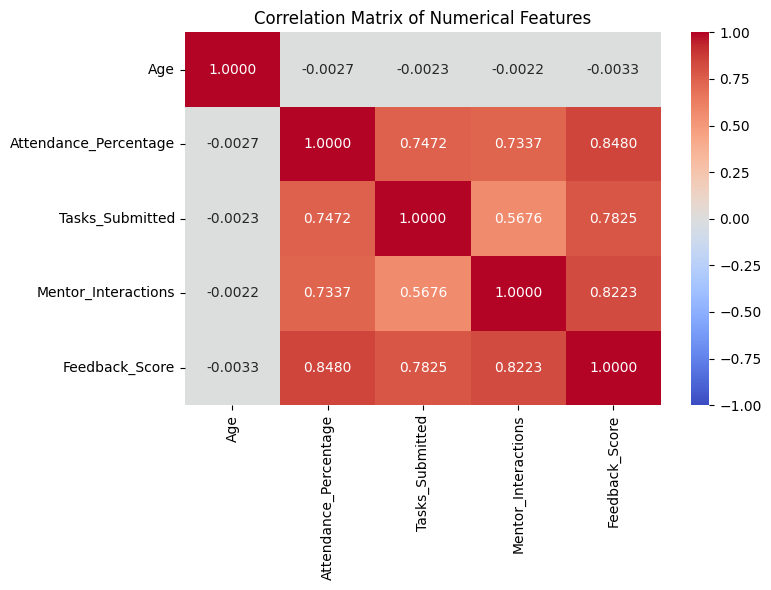

In [33]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".4f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/14_Correlation_Heatmap.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The correlation analysis reveals that **Feedback_Score** has the strongest positive correlation with **Attendance_Percentage** (0.85), followed by **Mentor_Interactions** (0.82) and **Tasks_Submitted** (0.78). This indicates that interns with better attendance, frequent mentor interactions, and higher task completion generally receive better feedback scores.

Furthermore, **Attendance_Percentage** is strongly correlated with **Tasks_Submitted** (0.75) and **Mentor_Interactions** (0.73), suggesting that interns who regularly attend the internship program are more engaged in completing tasks and communicating with mentors.

On the other hand, **Age** has negligible correlation with all other numerical features, with correlation coefficients close to zero. This suggests that age has little influence on internship engagement or performance-related activities in the dataset.

**Key Insights**

- **Feedback_Score** is the feature most strongly associated with internship engagement metrics.
- Higher **Attendance_Percentage** is positively associated with greater **Tasks_Submitted** and **Mentor_Interactions**.
- **Mentor_Interactions** and **Tasks_Submitted** contribute positively to higher **Feedback_Score**.
- **Age** has minimal influence on internship performance-related features.

### Relationship Analysis

Relationship Analysis examines how different internship-related features are associated with one another and with intern performance. Unlike univariate analysis, this section focuses on comparing groups, identifying patterns, and evaluating factors that may influence internship outcomes. These insights provide a better understanding of intern engagement, mentor evaluations, and performance across departments, internship tracks, education levels, and gender.

#### Average Feedback Score by Department

This analysis compares the average mentor feedback score across different internship departments. It helps identify which departments receive higher mentor evaluations and highlights variations in feedback among departments.

In [34]:
# Display average feedback score by department
department_feedback = (
    df.groupby("Department")["Feedback_Score"]
      .mean()
      .sort_values(ascending=False)
)

department_feedback

Department
Chatbot Development     3.821518
Other Internships       3.813070
Frontend Development    3.810072
Backend Development     3.807366
Graphic Design          3.807052
App Development         3.805471
Name: Feedback_Score, dtype: float64

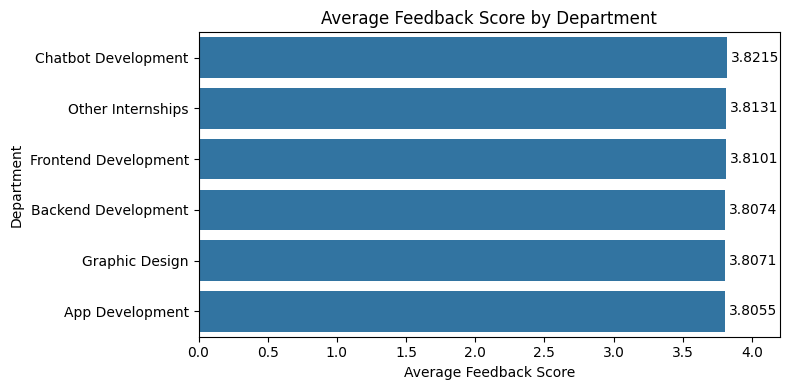

In [35]:
# Plot average feedback score by department
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=df,
    y="Department",
    x="Feedback_Score",
    estimator="mean",
    errorbar=None,
    order=department_feedback.index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, department_feedback.max() * 1.10)

plt.title("Average Feedback Score by Department")

plt.ylabel("Department")
plt.xlabel("Average Feedback Score")


plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/15_Average_Feedback_Score_by_Department.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The average feedback scores are highly consistent across all internship departments, with only slight variations. Chatbot Development has the highest average feedback score, while App Development has the lowest average. Overall, mentor evaluations remain relatively uniform across departments.

**Key Insights**

- Average feedback scores are very similar across all internship departments.
- Chatbot Development has the highest average mentor feedback score.
- App Development has the lowest average feedback score, although the difference is minimal.
- Mentor evaluations appear to be consistent across different internship departments.

#### Average Attendance Percentage by Internship Track

This analysis compares the average attendance percentage across different internship tracks. It helps identify which internship tracks demonstrate higher attendance and provides insights into intern participation across various specializations.

In [36]:
# Display average attendance percentage by internship track
track_attendance = (
    df.groupby("Internship_Track")["Attendance_Percentage"]
      .mean()
      .sort_values(ascending=False)
)

track_attendance

Internship_Track
Salesforce CRM      83.673624
Cloud Computing     83.057998
RASA                82.976848
Data Science        82.844499
Next.js             82.680583
Autodesk Maya       82.647793
Django              82.617994
Swift               82.587344
React Native        82.562211
Web 3.0             82.542636
React               82.517786
MEAN Stack          82.512933
Video Editing       82.451818
Node.js             82.433552
Social Media        82.392723
Alexa Skill         82.381679
Photoshop           82.376878
Angular             82.350348
WordPress           82.342330
Machine Learning    82.292716
HTML CSS JS         82.282440
Dialogflow          82.270698
Data Analytics      82.264111
Figma               82.244726
MERN Stack          82.224468
PHP                 82.211735
Generative AI       82.211599
Cyber Security      82.186414
Android             82.170859
Flutter             82.096803
Illustrator         82.095000
.NET Core           81.896892
Name: Attendance_Percen

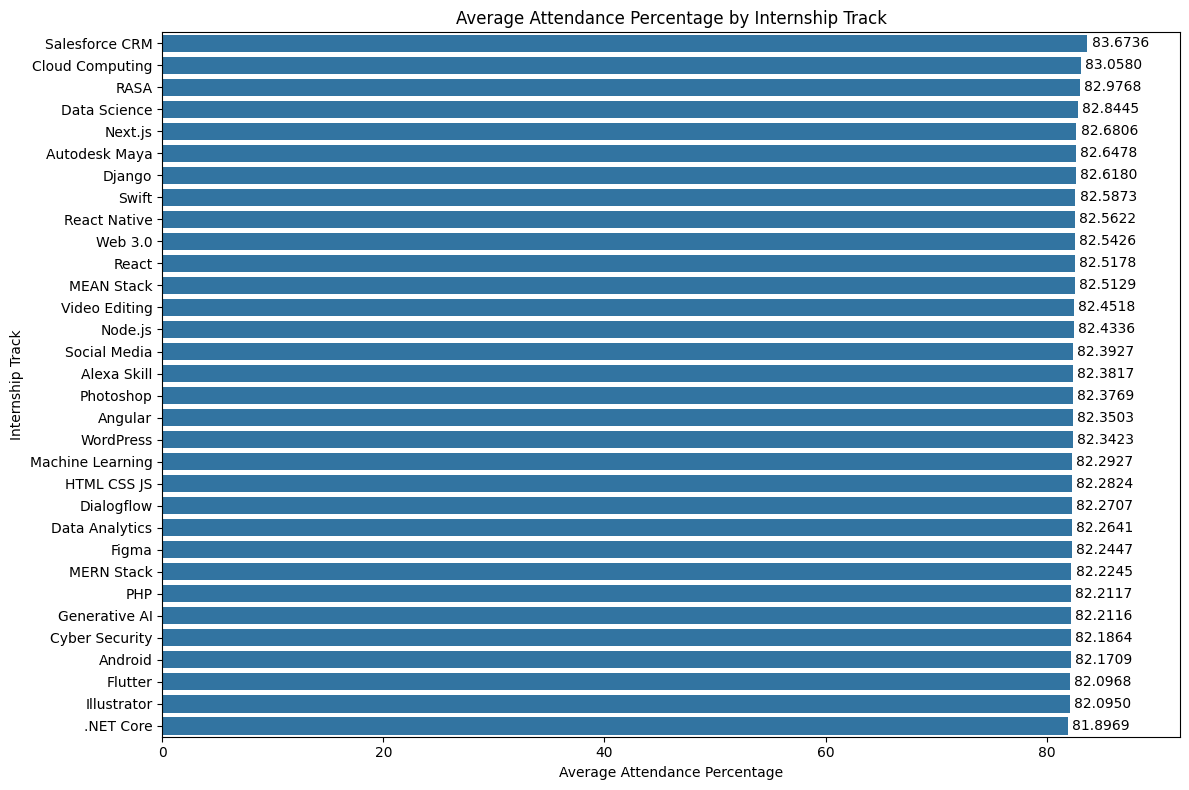

In [37]:
# Plot average attendance percentage by internship track
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df,
    y="Internship_Track",
    x="Attendance_Percentage",
    errorbar=None,
    order=track_attendance.index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, track_attendance.max() * 1.10)

plt.title("Average Attendance Percentage by Internship Track")

plt.ylabel("Internship Track")
plt.xlabel("Average Attendance Percentage")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/16_Average_Attendance_Percentage_by_Track.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The average attendance percentage is highly consistent across all internship tracks, with values ranging from approximately **81.90%** to **83.67%**. Salesforce CRM has the highest average attendance percentage, while .NET Core records the lowest average attendance. Overall, the differences among internship tracks are relatively small, indicating consistent attendance across the internship program.

**Key Insights**

- Average attendance percentages are very similar across all internship tracks.
- Salesforce CRM records the highest average attendance percentage.
- .NET Core has the lowest average attendance percentage, although the difference is minimal.
- The narrow range of attendance values suggests that interns maintain consistent participation regardless of their internship track.

#### Average Tasks Submitted by Department

This analysis compares the average number of tasks submitted by interns across different internship departments. It helps identify departments where interns demonstrate higher task completion and overall participation during the internship program.

In [38]:
# Display average tasks submitted by department
department_tasks = (
    df.groupby("Department")["Tasks_Submitted"]
      .mean()
      .sort_values(ascending=False)
)

department_tasks

Department
Chatbot Development     7.071848
Backend Development     7.060706
App Development         7.060590
Frontend Development    7.052763
Other Internships       7.050763
Graphic Design          7.041240
Name: Tasks_Submitted, dtype: float64

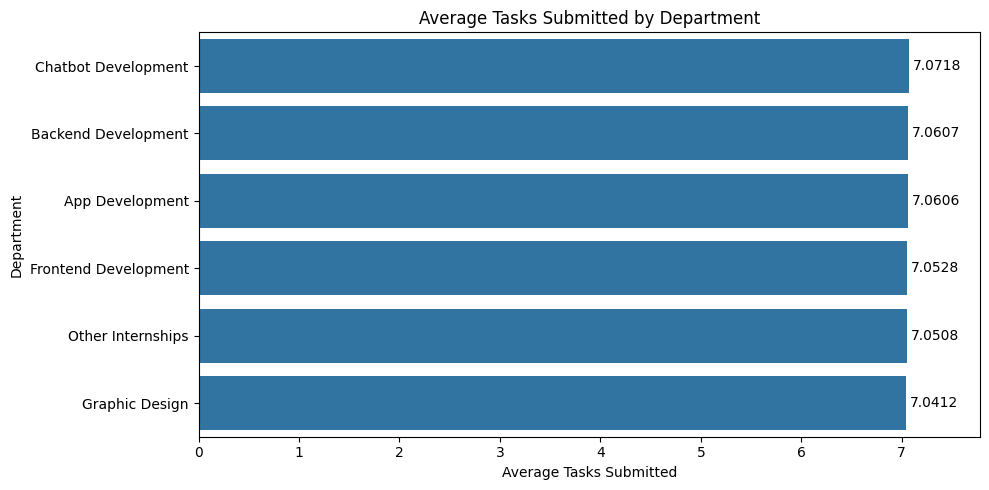

In [39]:
# Plot average tasks submitted by department
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    y="Department",
    x="Tasks_Submitted",
    errorbar=None,
    order=department_tasks.index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, department_tasks.max() * 1.10)

plt.title("Average Tasks Submitted by Department")

plt.ylabel("Department")
plt.xlabel("Average Tasks Submitted")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/17_Average_Tasks_Submitted_by_Department.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The average number of tasks submitted is highly consistent across all internship departments, ranging from approximately **7.04** to **7.07** tasks. Chatbot Development has the highest average task submission, while Graphic Design records the lowest average. However, the differences between departments are minimal, indicating a similar level of task completion throughout the internship program.

**Observation**

The average number of tasks submitted is highly consistent across all internship departments, ranging from approximately **7.04** to **7.07** tasks. Chatbot Development has the highest average task submission, while Graphic Design records the lowest average. However, the differences between departments are minimal, indicating a similar level of task completion throughout the internship program.

#### Average Mentor Interactions by Internship Track

This analysis compares the average number of mentor interactions across different internship tracks. It helps evaluate how frequently interns communicate with their mentors and identifies tracks with higher levels of mentor engagement.

In [40]:
# Display average mentor interactions by internship track
track_interactions = (
    df.groupby("Internship_Track")["Mentor_Interactions"]
      .mean()
      .sort_values(ascending=False)
)

track_interactions

Internship_Track
Salesforce CRM      8.550285
Data Science        8.438631
Cloud Computing     8.424696
RASA                8.419412
Next.js             8.401456
Alexa Skill         8.383588
Video Editing       8.380909
Autodesk Maya       8.357965
Django              8.353245
React               8.348447
MEAN Stack          8.329664
React Native        8.327836
Data Analytics      8.314164
Web 3.0             8.309302
WordPress           8.300197
Node.js             8.299869
Flutter             8.297957
Dialogflow          8.297674
Illustrator         8.295385
Angular             8.292923
HTML CSS JS         8.292857
Android             8.290546
Social Media        8.288582
Cyber Security      8.286730
Generative AI       8.285908
PHP                 8.284439
Swift               8.284314
MERN Stack          8.283539
Photoshop           8.282725
Figma               8.260954
Machine Learning    8.219877
.NET Core           8.146323
Name: Mentor_Interactions, dtype: float64

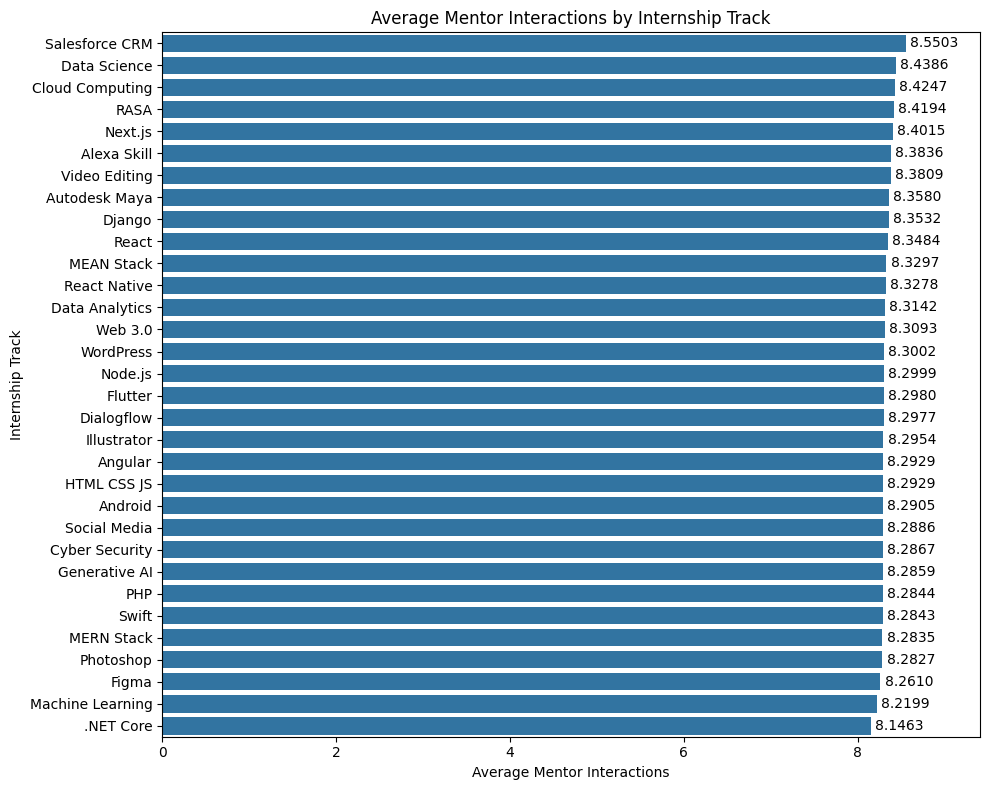

In [41]:
# Plot average mentor interactions by internship track
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=df,
    y="Internship_Track",
    x="Mentor_Interactions",
    errorbar=None,
    order=track_interactions.index
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, track_interactions.max() * 1.10)

plt.title("Average Mentor Interactions by Internship Track")

plt.ylabel("Internship Track")
plt.xlabel("Average Mentor Interactions")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/18_Average_Mentor_Interactions_by_Track.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The average number of mentor interactions is highly consistent across all internship tracks, ranging from approximately **8.15** to **8.55** interactions. Salesforce CRM records the highest average mentor interactions, while .NET Core has the lowest average. Overall, the variation across internship tracks is relatively small, indicating a consistent level of mentor engagement throughout the internship program.

**Key Insights**

- Average mentor interactions are very similar across all internship tracks.
- Salesforce CRM has the highest average number of mentor interactions.
- .NET Core records the lowest average mentor interactions, although the difference is relatively small.
- The narrow variation suggests that interns receive a consistent level of mentor support regardless of their internship track.

#### Performance Status by Department

This analysis examines the distribution of intern performance status across different internship departments. It helps identify whether certain departments have a higher proportion of high-performing interns and highlights performance patterns across departments.

In [42]:
# Display performance status by department
department_performance = (
    pd.crosstab(
        df["Department"],
        df["Performance_Status"]
    )
)

department_performance

Performance_Status,Average,Excellent,Good,Poor
Department,,,,
App Development,1679,4984,4444,281
Backend Development,2270,6831,5947,387
Chatbot Development,781,2416,2121,138
Frontend Development,2409,7419,6581,440
Graphic Design,1545,4624,4007,275
Other Internships,1545,4633,3975,268


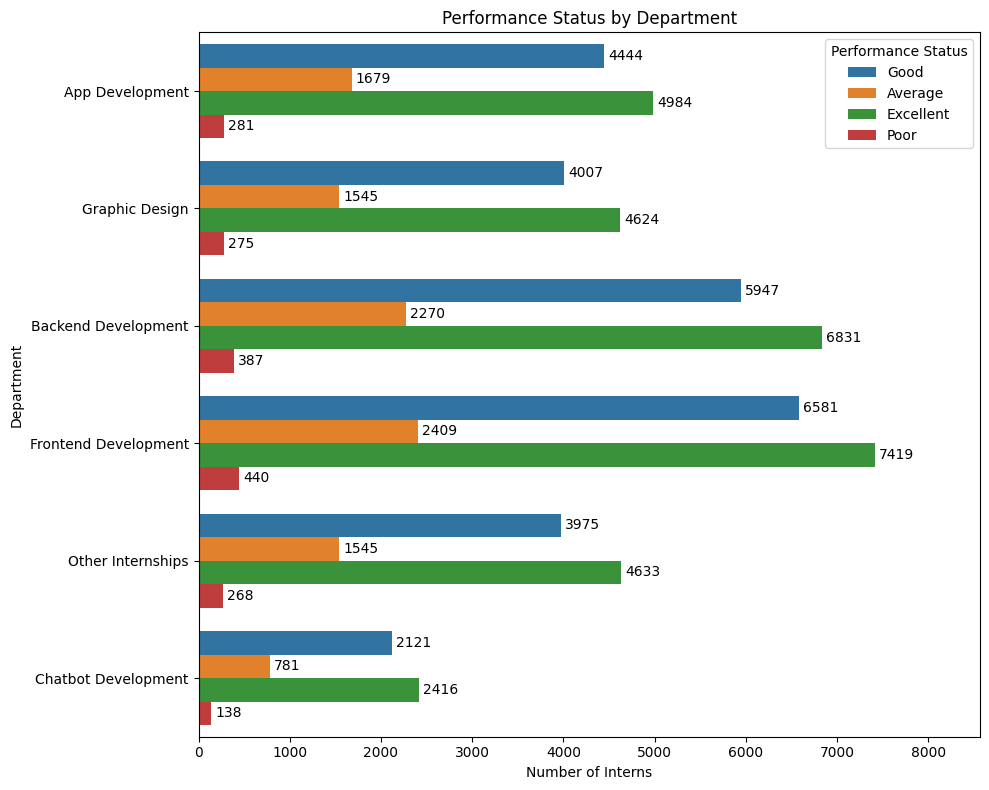

In [43]:
# Plot performance status by department
plt.figure(figsize=(10, 8))

ax = sns.countplot(
    data=df,
    y="Department",
    hue="Performance_Status"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, ax.get_xlim()[1] * 1.10)

plt.title("Performance Status by Department")

plt.ylabel("Department")
plt.xlabel("Number of Interns")

plt.legend(title="Performance Status")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/19_Performance_Status_by_Department.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The distribution of performance status varies across internship departments. In every department, **Excellent** is the most common performance category, followed by **Good**, while **Average** and **Poor** account for a much smaller proportion of interns. Frontend Development records the highest number of interns across all performance categories, whereas Chatbot Development has the lowest overall counts.

**Key Insights**

- **Excellent** is the dominant performance status in every internship department.
- **Good** is the second most common performance category across all departments.
- **Poor** performance represents only a small proportion of interns in each department.
- Frontend Development has the highest number of interns with Excellent and Good performance.
- Chatbot Development has the lowest number of interns across all performance categories, indicating a smaller department size rather than weaker performance.

#### Performance Status by Education Level

This analysis examines the distribution of intern performance status across different education levels. It helps identify whether interns from different educational backgrounds demonstrate different performance patterns during the internship program.

In [44]:
# Display performance status by education
education_performance = pd.crosstab(
    df["Education"],
    df["Performance_Status"]
)

education_performance

Performance_Status,Average,Excellent,Good,Poor
Education,,,,
BBA,210,584,514,40
BS Artificial Intelligence,519,1608,1316,80
BS Computer Engineering,301,882,799,54
BS Computer Science,1829,5425,4858,299
BS Cyber Security,369,1282,1117,73
BS Data Analytics,530,1543,1334,90
BS Data Science,605,1821,1581,114
BS Information Technology,1196,3604,3217,210
BS Software Engineering,1220,3718,3192,238


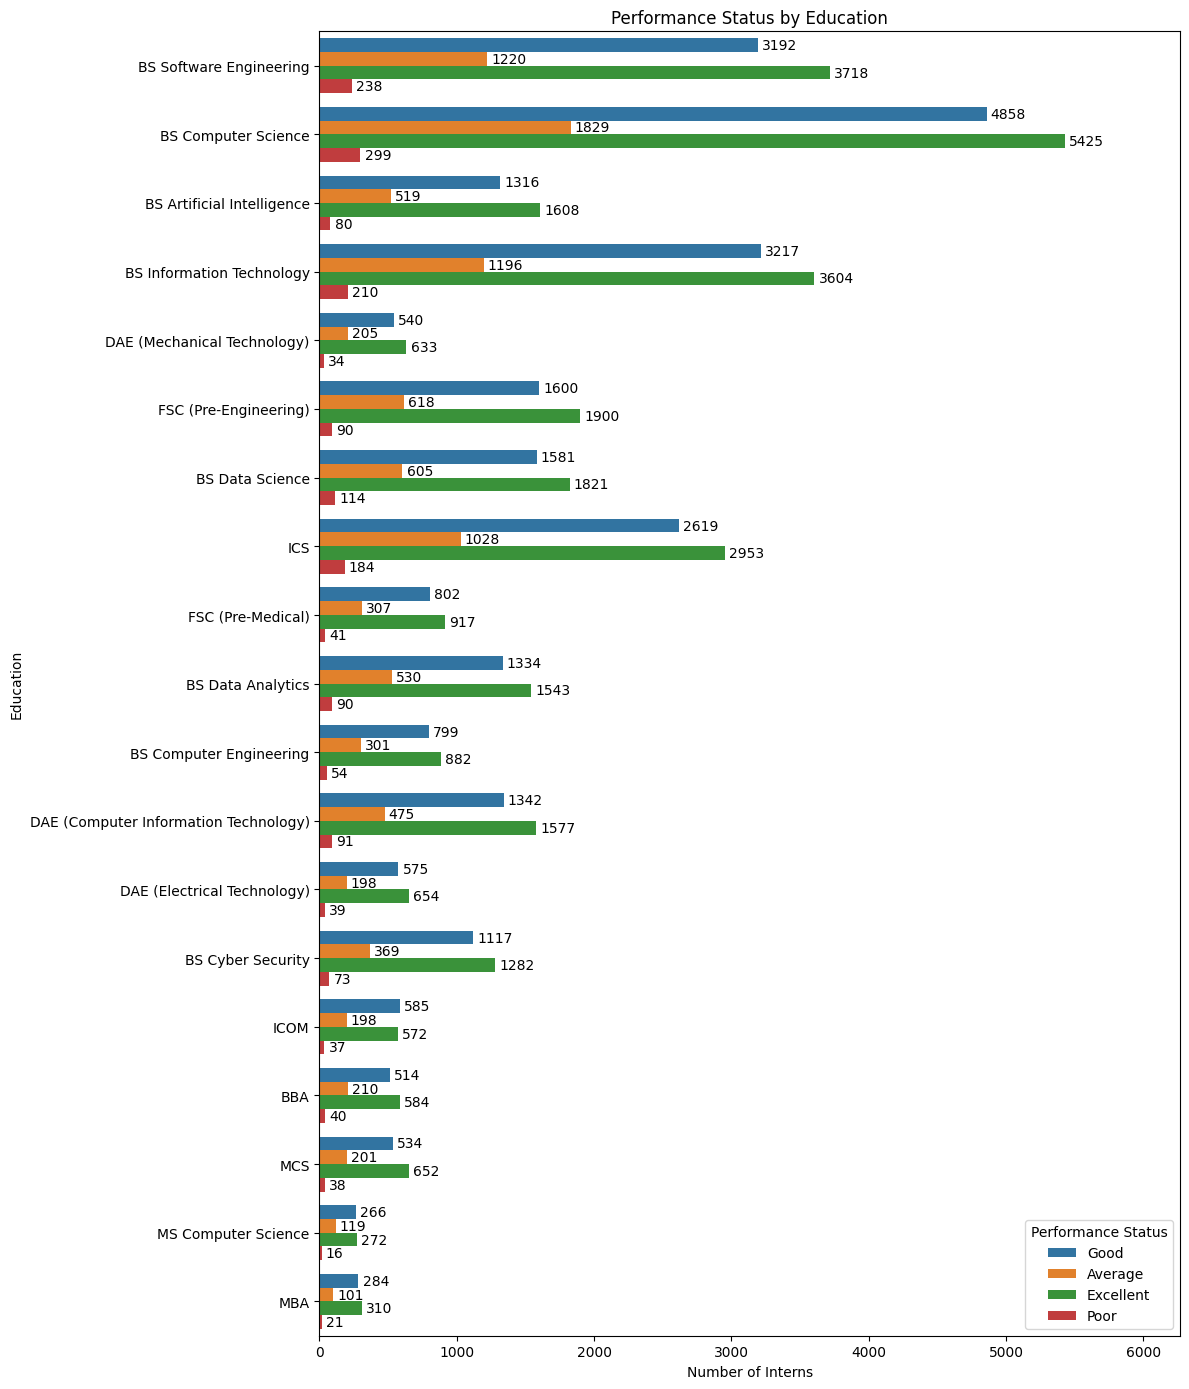

In [45]:
# Plot performance status by education
plt.figure(figsize=(12, 14))

ax = sns.countplot(
    data=df,
    y="Education",
    hue="Performance_Status"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, ax.get_xlim()[1] * 1.10)

plt.title("Performance Status by Education")

plt.ylabel("Education")
plt.xlabel("Number of Interns")

plt.legend(title="Performance Status")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/20_Performance_Status_by_Education.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The distribution of performance status varies across different education categories. In every education group, **Excellent** is the most common performance status, followed by **Good**, while **Average** and **Poor** account for a smaller proportion of interns. BS Computer Science records the highest number of interns across all performance categories, whereas postgraduate and diploma programs generally have fewer interns.

**Key Insights**

- **Excellent** is the dominant performance status across all education categories.
- **Good** is consistently the second most common performance category.
- **Poor** performance represents only a small proportion of interns regardless of their educational background.
- BS Computer Science has the largest number of interns with Excellent and Good performance, reflecting the highest participation in the internship program.
- Differences in counts mainly reflect the number of interns enrolled in each education category rather than substantial differences in performance patterns.

#### Performance Status by Gender

This analysis examines the distribution of intern performance status by gender. It helps compare performance patterns between male and female interns and identify whether performance levels differ across gender groups.

In [46]:
# Display performance status by gender
gender_performance = pd.crosstab(
    df["Gender"],
    df["Performance_Status"]
)

gender_performance

Performance_Status,Average,Excellent,Good,Poor
Gender,,,,
Female,3773,11252,9821,660
Male,6456,19655,17254,1129


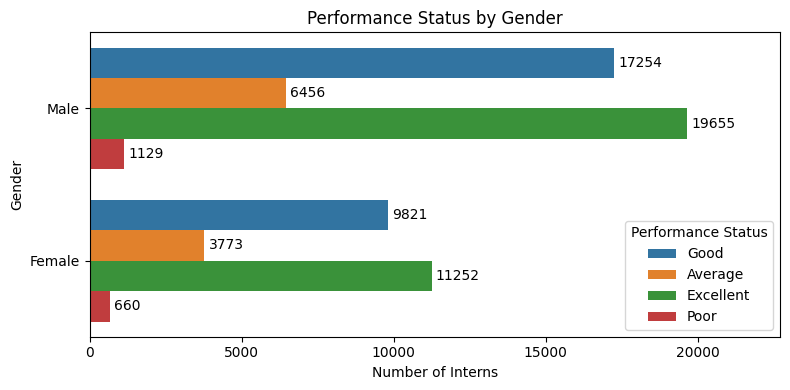

In [47]:
# Plot performance status by gender
plt.figure(figsize=(8, 4))

ax = sns.countplot(
    data=df,
    y="Gender",
    hue="Performance_Status"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Increase x-axis limit for data labels
plt.xlim(0, ax.get_xlim()[1] * 1.10)

plt.title("Performance Status by Gender")

plt.ylabel("Gender")
plt.xlabel("Number of Interns")

plt.legend(title="Performance Status")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/21_Performance_Status_by_Gender.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

**Observation**

The distribution of performance status is similar for both male and female interns. For each gender, **Excellent** is the most common performance status, followed by **Good**, while **Average** and **Poor** represent smaller proportions. Male interns have higher counts across all performance categories, reflecting their larger representation in the internship dataset.

**Key Insights**

- **Excellent** is the most common performance status for both male and female interns.
- **Good** is consistently the second most frequent performance category across both genders.
- **Poor** performance accounts for only a small proportion of interns regardless of gender.
- Male interns have higher counts in every performance category due to their greater participation in the internship program.
- Overall, both genders exhibit a similar performance distribution, suggesting that gender does not substantially influence performance patterns in this dataset.

## Machine Learning

### Data Preprocessing for Machine Learning

Before training the machine learning models, the cleaned dataset is prepared for predictive analysis. A separate copy of the dataset is created to preserve the original dataset used during exploratory data analysis (EDA). All preprocessing tasks, including feature engineering, feature selection, categorical encoding, and data transformation, will be performed on the copied dataset to ensure that the original data remains unchanged throughout the machine learning workflow.

In [48]:
# Create a copy of the cleaned dataset
ml_df = df.copy()

print("Original Dataset Shape:", df.shape)
print("Machine Learning Dataset Shape:", ml_df.shape)

Original Dataset Shape: (70000, 20)
Machine Learning Dataset Shape: (70000, 20)


#### Dataset Overview

The copied dataset is examined to review the available features, data types, and overall structure. This inspection helps identify categorical and numerical variables, detect unnecessary features, and determine the preprocessing steps required before building the machine learning models.

In [49]:
# Display dataset information
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Intern_ID                  70000 non-null  str           
 1   Intern_Name                70000 non-null  str           
 2   Gender                     70000 non-null  str           
 3   Age                        70000 non-null  int64         
 4   City                       70000 non-null  str           
 5   Education                  70000 non-null  str           
 6   Institute                  70000 non-null  str           
 7   Department                 70000 non-null  str           
 8   Internship_Track           70000 non-null  str           
 9   Mentor_ID                  70000 non-null  str           
 10  Mentor_Name                70000 non-null  str           
 11  Enrollment_Date            70000 non-null  datetime64[us]
 12  Internship_Dura

**Observation**

The machine learning dataset contains **70,000 records** and **20 features** with no missing values, indicating that the dataset is complete and ready for preprocessing. It includes a mixture of **categorical (11)**, **numerical (8)**, and **datetime (1)** features. The presence of identifier columns (such as `Intern_ID` and `Mentor_ID`), categorical variables, and a datetime feature indicates that additional preprocessing steps, including feature selection, feature engineering, and categorical encoding, will be required before training the machine learning models.

#### Removing Irrelevant Features

The dataset contains a few columns that serve only as unique identifiers or descriptive information. These features do not provide meaningful patterns for predicting intern performance and may introduce unnecessary complexity into the machine learning model. Therefore, they are removed before further preprocessing.

The following columns are removed:

- **Intern_ID** – Unique identifier for each intern.
- **Intern_Name** – Personal information that does not contribute to prediction.
- **Mentor_ID** – Unique identifier for mentors.
- **Mentor_Name** – Descriptive information without predictive value.

In [50]:
# Remove irrelevant features
ml_df.drop(
    columns=[
        "Intern_ID",
        "Intern_Name",
        "Mentor_ID",
        "Mentor_Name"
    ],
    inplace=True
)

print("Updated Dataset Shape:", ml_df.shape)

Updated Dataset Shape: (70000, 16)


In [51]:
# Display updated dataset information
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Gender                     70000 non-null  str           
 1   Age                        70000 non-null  int64         
 2   City                       70000 non-null  str           
 3   Education                  70000 non-null  str           
 4   Institute                  70000 non-null  str           
 5   Department                 70000 non-null  str           
 6   Internship_Track           70000 non-null  str           
 7   Enrollment_Date            70000 non-null  datetime64[us]
 8   Internship_Duration_Weeks  70000 non-null  int64         
 9   Weeks_Completed            70000 non-null  int64         
 10  Attendance_Percentage      70000 non-null  int64         
 11  Tasks_Assigned             70000 non-null  int64         
 12  Tasks_Submitted

**Observation**

After removing the identifier and descriptive columns, the dataset size has been reduced from **20** to **16 features**, while the total number of records remains unchanged at **70,000**. The remaining dataset consists of **7 categorical**, **7 numerical**, **1 datetime**, and **1 target** feature. These remaining features are more relevant for predicting intern performance and will be further processed in the subsequent preprocessing steps.

#### Removing Enrollment Date

The `Enrollment_Date` column is not directly related to predicting intern performance. Since the project focuses on intern engagement, task completion, attendance, mentor interactions, and feedback, this datetime feature does not provide meaningful predictive value. Therefore, it is removed to simplify the dataset before applying machine learning techniques.

In [52]:
# Remove the enrollment date feature
ml_df.drop(columns=["Enrollment_Date"], inplace=True)

print("Updated Dataset Shape:", ml_df.shape)

Updated Dataset Shape: (70000, 15)


In [53]:
# Display updated dataset information
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     70000 non-null  str    
 1   Age                        70000 non-null  int64  
 2   City                       70000 non-null  str    
 3   Education                  70000 non-null  str    
 4   Institute                  70000 non-null  str    
 5   Department                 70000 non-null  str    
 6   Internship_Track           70000 non-null  str    
 7   Internship_Duration_Weeks  70000 non-null  int64  
 8   Weeks_Completed            70000 non-null  int64  
 9   Attendance_Percentage      70000 non-null  int64  
 10  Tasks_Assigned             70000 non-null  int64  
 11  Tasks_Submitted            70000 non-null  int64  
 12  Mentor_Interactions        70000 non-null  int64  
 13  Feedback_Score             70000 non-null  float64
 14  P

**Observation**

After removing the `Enrollment_Date` column, the dataset now contains **15 features** while preserving all **70,000 records**. The remaining features include **7 numerical**, **7 categorical**, and **1 target** variable, providing a clean and relevant dataset for the next preprocessing step of categorical encoding.

#### Encoding the Target Variable

Machine learning algorithms require the target variable to be in numerical form. Therefore, the `Performance_Status` column is converted from categorical labels into numerical values using label encoding. This transformation preserves each class as a unique numerical label while preparing the target variable for model training.

In [54]:
# Display unique values in the target variable
ml_df["Performance_Status"].value_counts()

Performance_Status
Excellent    30907
Good         27075
Average      10229
Poor          1789
Name: count, dtype: int64

In [55]:
# Initialize LabelEncoder
ml_label_encoder = LabelEncoder()

# Encode the target variable
ml_df["Performance_Status"] = ml_label_encoder.fit_transform(
    ml_df["Performance_Status"]
)

# Display encoded class mapping
class_mapping = dict(
    zip(ml_label_encoder.classes_, ml_label_encoder.transform(ml_label_encoder.classes_))
)

print("Encoded Class Mapping:")
print(class_mapping)

Encoded Class Mapping:
{'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3)}


In [56]:
# Display encoded target variable
ml_df["Performance_Status"].value_counts().sort_index()

Performance_Status
0    10229
1    30907
2    27075
3     1789
Name: count, dtype: int64

**Observation**

The `Performance_Status` column has been successfully encoded into numerical labels using **LabelEncoder**. Each performance category has been assigned a unique integer value while preserving its class identity. The encoded target variable is now suitable for machine learning models that require numerical input for training and prediction.

#### Identifying Categorical Features

Before applying categorical encoding, the categorical features are examined to determine the number of unique categories in each feature. This inspection helps in selecting an appropriate encoding technique and understanding how the transformation may affect the dataset.

In [57]:
# List of machine learning categorical features
ml_categorical_columns = [
    "Gender",
    "City",
    "Education",
    "Institute",
    "Department",
    "Internship_Track"
]

# Display the number of unique values in each categorical feature
for column in ml_categorical_columns:
    print(f"{column}: {ml_df[column].nunique()} unique values")

Gender: 2 unique values
City: 40 unique values
Education: 19 unique values
Institute: 31 unique values
Department: 6 unique values
Internship_Track: 32 unique values


**Observation**

The dataset contains six categorical features with varying numbers of unique categories. While `Gender` has only **2** unique values, other features such as `City`, `Education`, `Institute`, `Department`, and `Internship_Track` contain multiple categories. Since these features are nominal and do not have a natural ordering, they will be transformed using **One-Hot Encoding** to convert them into a machine learning-friendly numerical format without introducing artificial ordinal relationships.

#### Encoding Categorical Features

Machine learning models require categorical features to be converted into numerical values before training. Since the categorical features in this dataset are nominal and do not have any natural ordering, **One-Hot Encoding** is applied. To avoid redundant features and reduce dimensionality, the first category of each feature is dropped using `drop="first"`. This approach is widely used in machine learning workflows, particularly for regression-based models.

In [58]:
# Initialize OneHotEncoder for machine learning categorical features
ml_onehot_encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

# Apply One-Hot Encoding
ml_encoded_features = ml_onehot_encoder.fit_transform(
    ml_df[ml_categorical_columns]
)

print("Encoded Feature Shape:", ml_encoded_features.shape)

Encoded Feature Shape: (70000, 124)


**Observation**

The categorical features have been successfully transformed using **One-Hot Encoding**. By setting `drop="first"`, the first category of each feature is removed, reducing redundant columns while preserving all necessary information for model training. This preprocessing step converts the categorical features into a numerical format that is compatible with machine learning algorithms.

#### Converting Encoded Features into a DataFrame

The output generated by `OneHotEncoder` is a NumPy array without column names. To make the encoded data easier to understand and manage, it is converted into a pandas DataFrame using the automatically generated feature names. This improves readability and simplifies the subsequent preprocessing steps.

In [59]:
# Convert encoded features into a DataFrame
ml_encoded_df = pd.DataFrame(
    ml_encoded_features,
    columns=ml_onehot_encoder.get_feature_names_out(ml_categorical_columns),
    index=ml_df.index
).astype(int)

print("Encoded DataFrame Shape:", ml_encoded_df.shape)

Encoded DataFrame Shape: (70000, 124)


In [60]:
# Display the first five rows of all encoded columns
pd.set_option("display.max_columns", None)

ml_encoded_df.head()

,Gender_Male,City_Bahawalpur,City_Bannu,City_Chiniot,City_Dera Ghazi Khan,City_Faisalabad,City_Gujranwala,City_Gujrat,City_Gwadar,City_Hyderabad,City_Islamabad,City_Jacobabad,City_Jhang,City_Karachi,City_Kasur,City_Khushab,City_Kohat,City_Lahore,City_Larkana,City_Mardan,City_Mingora,City_Mirpur Khas,City_Multan,City_Muzaffarabad,City_Nawabshah,City_Nowshera,City_Okara,City_Pakpattan,City_Peshawar,City_Quetta,City_Rahim Yar Khan,City_Rawalpindi,City_Sahiwal,City_Sargodha,City_Sheikhupura,City_Sialkot,City_Sukkur,City_Turbat,City_Vehari,City_Wah Cantt,Education_BS Artificial Intelligence,Education_BS Computer Engineering,Education_BS Computer Science,Education_BS Cyber Security,Education_BS Data Analytics,Education_BS Data Science,Education_BS Information Technology,Education_BS Software Engineering,Education_DAE (Computer Information Technology),Education_DAE (Electrical Technology),Education_DAE (Mechanical Technology),Education_FSC (Pre-Engineering),Education_FSC (Pre-Medical),Education_ICOM,Education_ICS,Education_MBA,Education_MCS,Education_MS Computer Science,Institute_Aspire College,Institute_Bahria University,Institute_COMSATS University Islamabad,Institute_Chenab College,Institute_FAST National University,Institute_Government College Faisalabad,Institute_Government College Jhang,Institute_Government College Lahore,Institute_Government College University Faisalabad,Institute_Government College of Technology,Institute_Government Post Graduate College,Institute_Government Technical Training Institute,Institute_Iqra University,Institute_KIPS College,Institute_National University of Sciences and Technology,Institute_Punjab College,Institute_Punjab Group of Colleges,Institute_Punjab Polytechnic Institute,Institute_Riphah International University,Institute_Superior College,Institute_Superior University,Institute_Swedish Institute of Technology,Institute_TEVTA Institute,Institute_University of Central Punjab,Institute_University of Education,Institute_University of Engineering and Technology,Institute_University of Management and Technology,Institute_University of the Punjab,Institute_Virtual University of Pakistan,Institute_Vocational Training Institute (VTI),Department_Backend Development,Department_Chatbot Development,Department_Frontend Development,Department_Graphic Design,Department_Other Internships,Internship_Track_Alexa Skill,Internship_Track_Android,Internship_Track_Angular,Internship_Track_Autodesk Maya,Internship_Track_Cloud Computing,Internship_Track_Cyber Security,Internship_Track_Data Analytics,Internship_Track_Data Science,Internship_Track_Dialogflow,Internship_Track_Django,Internship_Track_Figma,Internship_Track_Flutter,Internship_Track_Generative AI,Internship_Track_HTML CSS JS,Internship_Track_Illustrator,Internship_Track_MEAN Stack,Internship_Track_MERN Stack,Internship_Track_Machine Learning,Internship_Track_Next.js,Internship_Track_Node.js,Internship_Track_PHP,Internship_Track_Photoshop,Internship_Track_RASA,Internship_Track_React,Internship_Track_React Native,Internship_Track_Salesforce CRM,Internship_Track_Social Media,Internship_Track_Swift,Internship_Track_Video Editing,Internship_Track_Web 3.0,Internship_Track_WordPress
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

**Observation**

The categorical features have been successfully transformed into **124 binary encoded columns** using One-Hot Encoding with `drop="first"`. Each encoded column represents a unique category, where **1** indicates the presence of a category and **0** indicates its absence. The encoded features are now stored in a separate DataFrame (`ml_encoded_df`), making them ready to replace the original categorical features in the machine learning dataset.

#### Replacing Original Categorical Features

After applying One-Hot Encoding, the original categorical features are no longer required because their information has been converted into binary encoded columns. The original categorical columns are removed, and the encoded features are combined with the remaining numerical features to create the final machine learning dataset.

In [61]:
# Remove the original categorical features
ml_df.drop(
    columns=ml_categorical_columns,
    inplace=True
)

# Combine the encoded features with the remaining dataset
ml_df = pd.concat(
    [ml_df, ml_encoded_df],
    axis=1
)

print("Final Machine Learning Dataset Shape:", ml_df.shape)

Final Machine Learning Dataset Shape: (70000, 133)


In [62]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 133 entries, Age to Internship_Track_WordPress
dtypes: float64(1), int64(132)
memory usage: 71.0 MB


In [63]:
pd.set_option("display.max_columns", None)

ml_df.head()

,Age,Internship_Duration_Weeks,Weeks_Completed,Attendance_Percentage,Tasks_Assigned,Tasks_Submitted,Mentor_Interactions,Feedback_Score,Performance_Status,Gender_Male,City_Bahawalpur,City_Bannu,City_Chiniot,City_Dera Ghazi Khan,City_Faisalabad,City_Gujranwala,City_Gujrat,City_Gwadar,City_Hyderabad,City_Islamabad,City_Jacobabad,City_Jhang,City_Karachi,City_Kasur,City_Khushab,City_Kohat,City_Lahore,City_Larkana,City_Mardan,City_Mingora,City_Mirpur Khas,City_Multan,City_Muzaffarabad,City_Nawabshah,City_Nowshera,City_Okara,City_Pakpattan,City_Peshawar,City_Quetta,City_Rahim Yar Khan,City_Rawalpindi,City_Sahiwal,City_Sargodha,City_Sheikhupura,City_Sialkot,City_Sukkur,City_Turbat,City_Vehari,City_Wah Cantt,Education_BS Artificial Intelligence,Education_BS Computer Engineering,Education_BS Computer Science,Education_BS Cyber Security,Education_BS Data Analytics,Education_BS Data Science,Education_BS Information Technology,Education_BS Software Engineering,Education_DAE (Computer Information Technology),Education_DAE (Electrical Technology),Education_DAE (Mechanical Technology),Education_FSC (Pre-Engineering),Education_FSC (Pre-Medical),Education_ICOM,Education_ICS,Education_MBA,Education_MCS,Education_MS Computer Science,Institute_Aspire College,Institute_Bahria University,Institute_COMSATS University Islamabad,Institute_Chenab College,Institute_FAST National University,Institute_Government College Faisalabad,Institute_Government College Jhang,Institute_Government College Lahore,Institute_Government College University Faisalabad,Institute_Government College of Technology,Institute_Government Post Graduate College,Institute_Government Technical Training Institute,Institute_Iqra University,Institute_KIPS College,Institute_National University of Sciences and Technology,Institute_Punjab College,Institute_Punjab Group of Colleges,Institute_Punjab Polytechnic Institute,Institute_Riphah International University,Institute_Superior College,Institute_Superior University,Institute_Swedish Institute of Technology,Institute_TEVTA Institute,Institute_University of Central Punjab,Institute_University of Education,Institute_University of Engineering and Technology,Institute_University of Management and Technology,Institute_University of the Punjab,Institute_Virtual University of Pakistan,Institute_Vocational Training Institute (VTI),Department_Backend Development,Department_Chatbot Development,Department_Frontend Development,Department_Graphic Design,Department_Other Internships,Internship_Track_Alexa Skill,Internship_Track_Android,Internship_Track_Angular,Internship_Track_Autodesk Maya,Internship_Track_Cloud Computing,Internship_Track_Cyber Security,Internship_Track_Data Analytics,Internship_Track_Data Science,Internship_Track_Dialogflow,Internship_Track_Django,Internship_Track_Figma,Internship_Track_Flutter,Internship_Track_Generative AI,Internship_Track_HTML CSS JS,Internship_Track_Illustrator,Internship_Track_MEAN Stack,Internship_Track_MERN Stack,Internship_Track_Machine Learning,Internship_Track_Next.js,Internship_Track_Node.js,Internship_Track_PHP,Internship_Track_Photoshop,Internship_Track_RASA,Internship_Track_React,Internship_Track_React Native,Internship_Track_Salesforce CRM,Internship_Track_Social Media,Internship_Track_Swift,Internship_Track_Video Editing,Internship_Track_Web 3.0,Internship_Track_WordPress
0,20,8,8,85,8,7,9,3.6,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,22,8,8,61,8,7,4,3.3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,22,8,8,61,8,6,4,2.7,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

**Observation**

The final machine learning dataset has been successfully prepared after replacing the original categorical features with their One-Hot Encoded representations. The dataset now contains **70,000 records** and **133 numerical columns**, including the encoded target variable (`Performance_Status`). All categorical features have been converted into numerical values, resulting in **132 integer features** and **1 floating-point feature (`Feedback_Score`)**. Since no object or string data types remain, the dataset is fully compatible with machine learning algorithms and ready for feature selection, train-test splitting, and model training.

#### Saving the Preprocessed Dataset

After completing all preprocessing steps, the final machine learning dataset is saved in the **processed** folder. Saving the transformed dataset preserves the machine learning-ready version of the data and allows future model training without repeating the preprocessing steps. The original dataset remains unchanged in the **raw** folder.

In [64]:
# Save the preprocessed dataset

# ml_df.to_csv(
#     "../dataset/processed/intern_performance_2025_ml_preprocessed.csv",
#     index=False
# )

# print("Preprocessed dataset saved successfully.")

### Feature Selection

Feature selection is the process of separating the input features (independent variables) from the target variable (dependent variable). The input features contain the information used by machine learning algorithms to learn patterns from the dataset, while the target variable represents the outcome that the model is trained to predict.

In this project, all numerical and encoded features are selected as the input features (`ml_X`), whereas the encoded **Performance_Status** column is selected as the target variable (`ml_y`).

In [65]:
# Separate input features and target variable
ml_X = ml_df.drop(columns="Performance_Status")

ml_y = ml_df["Performance_Status"]

print("Input Features Shape:", ml_X.shape)
print("Target Variable Shape:", ml_y.shape)

Input Features Shape: (70000, 132)
Target Variable Shape: (70000,)


**Observation**

The input features (`ml_X`) and the target variable (`ml_y`) have been successfully separated. The feature matrix contains **70,000 records** with **132 input features**, while the target variable contains **70,000 encoded performance labels**. The dataset is now ready to be divided into training and testing sets for machine learning model development.

### Train-Test Split

Before training a machine learning model, the dataset is divided into two parts: a **training set** and a **testing set**. The training set is used to teach the model the relationships between the input features and the target variable, while the testing set is used to evaluate how well the trained model performs on unseen data.

In this project, **80%** of the data is used for training and **20%** is reserved for testing. The `stratify` parameter is applied to preserve the class distribution of the target variable in both datasets, and `random_state` is set to ensure reproducible results.

In [66]:
# Split the dataset into training and testing sets
ml_X_train, ml_X_test, ml_y_train, ml_y_test = train_test_split(
    ml_X,
    ml_y,
    test_size=0.20,
    random_state=42,
    stratify=ml_y
)

print("Training Features Shape:", ml_X_train.shape)
print("Testing Features Shape:", ml_X_test.shape)
print("Training Target Shape:", ml_y_train.shape)
print("Testing Target Shape:", ml_y_test.shape)

Training Features Shape: (56000, 132)
Testing Features Shape: (14000, 132)
Training Target Shape: (56000,)
Testing Target Shape: (14000,)


**Observation**

The dataset has been successfully split into training and testing sets using an **80:20 ratio**. The training set contains **56,000 records** with **132 input features**, while the testing set contains **14,000 records** with the same **132 input features**. The target variable has also been divided accordingly into **56,000 training labels** and **14,000 testing labels**. By using the `stratify` parameter, the class distribution of the target variable is preserved in both datasets, ensuring a fair and reliable evaluation of the machine learning models.

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for classification problems. It learns the relationship between the input features and the target variable by estimating the probability of each class. In this project, Logistic Regression is used as the baseline classification model to predict the performance status of interns.

In [67]:
# Create the Logistic Regression model
ml_logistic_regression_model = LogisticRegression(
    random_state=42,
    max_iter=10000
)

# Train the model
ml_logistic_regression_model.fit(
    ml_X_train,
    ml_y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

**Observation**

The Logistic Regression model has been successfully trained using the training dataset. During training, the model learned the relationship between the input features and the target variable. The model converged successfully with the specified training parameters and is now ready to predict the performance status of unseen internship records.

#### Making Predictions

After training, the Logistic Regression model is used to predict the performance status of the testing dataset. These predictions are then compared with the actual target values to evaluate the model's performance.

In [68]:
# Predict the performance status for the testing dataset
ml_logistic_predictions = ml_logistic_regression_model.predict(
    ml_X_test
)

**Observation**

The trained Logistic Regression model has successfully generated predictions for the testing dataset. These predicted values will now be compared with the actual target values to evaluate the classification performance of the model.

#### Model Evaluation

After generating predictions, the performance of the Logistic Regression model is evaluated using multiple classification metrics. These evaluation metrics provide insights into how accurately the model predicts the performance status of interns and help assess its overall classification performance.

In [69]:
# Calculate the accuracy of the Logistic Regression model
ml_logistic_accuracy = accuracy_score(
    ml_y_test,
    ml_logistic_predictions
)

print(f"Logistic Regression Accuracy: {ml_logistic_accuracy:.4f}")
print(f"Accuracy Percentage: {ml_logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.9041
Accuracy Percentage: 90.41%


**Observation**

The Logistic Regression model achieved an **accuracy of 90.41%** on the testing dataset. This indicates that the model correctly classified approximately **9 out of every 10 internship records**. The high accuracy suggests that the selected features provide sufficient information for predicting the performance status of interns. However, additional evaluation metrics such as the classification report and confusion matrix are required to assess the model's performance for each individual class.

In [70]:
# Display the classification report
print(
    classification_report(
        ml_y_test,
        ml_logistic_predictions
    )
)

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2046
           1       0.92      0.92      0.92      6181
           2       0.88      0.89      0.88      5415
           3       0.91      0.94      0.93       358

    accuracy                           0.90     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.90      0.90      0.90     14000



**Observation**

The Logistic Regression model demonstrated strong classification performance across all four performance classes: **Average (0)**, **Excellent (1)**, **Good (2)**, and **Poor (3)**. The **precision**, **recall**, and **F1-score** values range from **0.88 to 0.94**, indicating that the model accurately classified most internship performance categories. The **macro average** of **0.91** shows balanced performance across all classes, while the **weighted average** of **0.90** confirms consistent overall classification performance by considering the class distribution. These results indicate that the Logistic Regression model provides reliable predictions for the internship performance dataset.

#### Confusion Matrix

A confusion matrix provides a detailed summary of the model's classification performance by comparing the actual class labels with the predicted class labels. It helps identify correctly classified records as well as the types of misclassifications made by the model for each performance category.

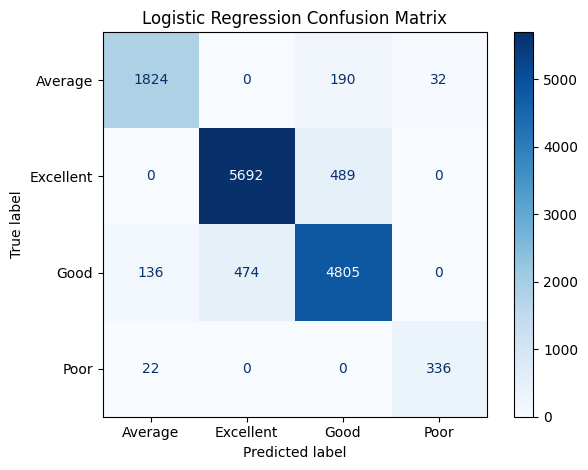

In [74]:
# Generate the confusion matrix
ml_logistic_confusion_matrix = confusion_matrix(
    ml_y_test,
    ml_logistic_predictions
)

# Display the confusion matrix
ml_logistic_confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=ml_logistic_confusion_matrix,
    display_labels=ml_label_encoder.classes_
)

ml_logistic_confusion_matrix_display.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")

# Save the figure
# plt.savefig(
#     "../outputs/figures/logistic_regression_confusion_matrix.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation**

The confusion matrix shows that the Logistic Regression model correctly classified the majority of internship records, as indicated by the high values along the diagonal. The model performed particularly well in predicting the **Excellent** and **Good** performance classes, while only a small number of records were misclassified into neighboring classes. The **Poor** class was also classified with high accuracy, with very few misclassifications. Overall, the confusion matrix confirms that the Logistic Regression model provides strong and reliable classification performance for the internship performance dataset.

### Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It learns decision rules from the training data by creating a tree-like structure, where each internal node represents a decision based on a feature, and each leaf node represents the predicted class. In this project, a Decision Tree Classifier is used to predict the performance status of interns based on the selected input features.

In [72]:
# Create the Decision Tree model
ml_decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
ml_decision_tree_model.fit(
    ml_X_train,
    ml_y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

**Observation**

The Decision Tree model has been successfully trained using the training dataset. During training, the model learned hierarchical decision rules from the input features to classify internship performance records. The trained model is now ready to predict the performance status of unseen internship data.

#### Making Predictions

After training, the Decision Tree model is used to predict the performance status of the testing dataset. These predictions are then compared with the actual target values to evaluate the model's classification performance using various evaluation metrics.

In [75]:
# Predict the performance status for the testing dataset
ml_decision_tree_predictions = ml_decision_tree_model.predict(
    ml_X_test
)

**Observation**

The Decision Tree model has successfully generated predictions for the testing dataset. These predicted performance labels will be compared with the actual target values to evaluate the model using accuracy, classification report, and confusion matrix.

#### Model Evaluation

After generating predictions, the performance of the Decision Tree model is evaluated using multiple classification metrics. These evaluation metrics provide insights into how accurately the model predicts the performance status of interns and help assess its overall classification performance.

In [76]:
# Calculate the accuracy of the Decision Tree model
ml_decision_tree_accuracy = accuracy_score(
    ml_y_test,
    ml_decision_tree_predictions
)

print(f"Decision Tree Accuracy: {ml_decision_tree_accuracy:.4f}")
print(f"Accuracy Percentage: {ml_decision_tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 0.8746
Accuracy Percentage: 87.46%


**Observation**

The Decision Tree model achieved an **accuracy of 87.46%** on the testing dataset. This indicates that the model correctly classified approximately **87 out of every 100 internship records**. Although the model demonstrates good classification performance, its accuracy is lower than that of the Logistic Regression model, suggesting that it is less effective in predicting the performance status of interns for this dataset. Further evaluation using the classification report and confusion matrix is required to analyze the model's performance for each individual class.

In [77]:
# Display the classification report
print(
    classification_report(
        ml_y_test,
        ml_decision_tree_predictions
    )
)

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      2046
           1       0.90      0.89      0.90      6181
           2       0.84      0.85      0.84      5415
           3       0.89      0.91      0.90       358

    accuracy                           0.87     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.87      0.87      0.87     14000



**Observation**

The Decision Tree model achieved an overall **accuracy of 87.46%**, demonstrating good classification performance across all performance categories. The model classified the **Excellent (Class 1)** and **Poor (Class 3)** categories most effectively, achieving F1-scores of **0.90** for both classes. The **Average (Class 0)** category also showed strong performance with an F1-score of **0.88**. However, the **Good (Class 2)** category was comparatively more difficult to classify, resulting in the lowest F1-score of **0.84**. The macro average (**0.88**) and weighted average (**0.87**) indicate that the model maintained consistent performance across the dataset, although its overall classification performance was slightly lower than that of the Logistic Regression model.

#### Confusion Matrix

A confusion matrix provides a detailed summary of the Decision Tree model's classification performance by comparing the actual class labels with the predicted class labels. It helps identify correctly classified records as well as the types of misclassifications made by the model for each performance category.

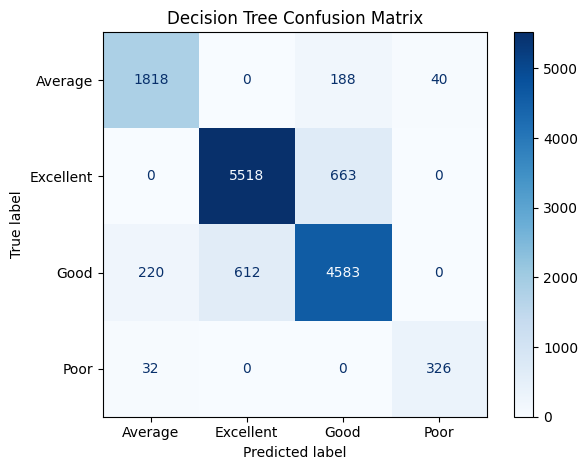

In [79]:
# Generate the confusion matrix
ml_decision_tree_confusion_matrix = confusion_matrix(
    ml_y_test,
    ml_decision_tree_predictions
)

# Display the confusion matrix
ml_decision_tree_confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=ml_decision_tree_confusion_matrix,
    display_labels=ml_label_encoder.classes_
)

ml_decision_tree_confusion_matrix_display.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Decision Tree Confusion Matrix")

# Save the figure
# plt.savefig(
#     "../outputs/figures/decision_tree_confusion_matrix.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation**

The confusion matrix shows that the Decision Tree model correctly classified the majority of internship records, as most predictions are concentrated along the main diagonal. The model performed particularly well in identifying the **Excellent** and **Good** performance categories, with **5,518** and **4,583** correct predictions, respectively. It also classified the **Average** (**1,818**) and **Poor** (**326**) categories with good accuracy. Most misclassifications occurred between the **Excellent** and **Good** categories, indicating that these two performance levels share similar characteristics and are more difficult for the model to distinguish. Overall, the confusion matrix confirms that the Decision Tree model provides reliable classification performance, although it makes more classification errors than the Logistic Regression model.

### Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve classification accuracy and reduce the risk of overfitting. Instead of relying on a single decision tree, it builds several trees using different subsets of the training data and combines their predictions through majority voting. This approach generally produces more accurate and robust predictions compared to a single Decision Tree model.

In [81]:
# Create the Random Forest model
ml_random_forest_model = RandomForestClassifier(
    random_state=42
)

# Train the model
ml_random_forest_model.fit(
    ml_X_train,
    ml_y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

**Observation**

The Random Forest model has been successfully trained using the training dataset. By combining multiple decision trees, the model learns complex patterns within the data while reducing the risk of overfitting. The trained model is now ready to predict the performance status of interns using the testing dataset.

#### Making Predictions

After training, the Random Forest model is used to predict the performance status of the testing dataset. These predictions are then compared with the actual target values to evaluate the model's classification performance using various evaluation metrics.

In [84]:
# Predict the performance status for the testing dataset
ml_random_forest_predictions = ml_random_forest_model.predict(
        ml_X_test
)

**Observation**

The Random Forest model has successfully generated predictions for the testing dataset. These predicted performance labels will be compared with the actual target values to evaluate the model using accuracy, classification report, and confusion matrix.

#### Model Evaluation

After generating predictions, the performance of the Random Forest model is evaluated using multiple classification metrics. These evaluation metrics provide insights into how accurately the model predicts the performance status of interns and help assess its overall classification performance.

In [85]:
# Calculate the accuracy of the Random Forest model
ml_random_forest_accuracy = accuracy_score(
    ml_y_test,
    ml_random_forest_predictions
)

print(f"Random Forest Accuracy: {ml_random_forest_accuracy:.4f}")
print(f"Accuracy Percentage: {ml_random_forest_accuracy * 100:.2f}%")

Random Forest Accuracy: 0.8989
Accuracy Percentage: 89.89%


**Observation**

The Random Forest model achieved an **accuracy of 89.89%** on the testing dataset, indicating that it correctly classified nearly **90 out of every 100 internship records**. The model demonstrated strong classification performance and outperformed the Decision Tree model. However, its accuracy was slightly lower than that of the Logistic Regression model, suggesting that Logistic Regression provided the best overall predictive performance for this dataset. Further evaluation using the classification report and confusion matrix will provide a more detailed understanding of the model's performance across individual classes.

In [86]:
# Display the classification report
print(
    classification_report(
        ml_y_test,
        ml_random_forest_predictions
    )
)

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2046
           1       0.92      0.92      0.92      6181
           2       0.87      0.88      0.88      5415
           3       0.93      0.90      0.91       358

    accuracy                           0.90     14000
   macro avg       0.91      0.90      0.90     14000
weighted avg       0.90      0.90      0.90     14000



**Observation**

The Random Forest model demonstrated strong classification performance with an overall **accuracy of 89.89%**. The model classified the **Excellent (Class 1)** category most effectively, achieving a precision, recall, and F1-score of **0.92**. The **Average (Class 0)** and **Poor (Class 3)** categories also showed excellent performance, with F1-scores of **0.91** each. The **Good (Class 2)** category remained the most challenging class to predict, resulting in an F1-score of **0.88**, although this represents an improvement over the Decision Tree model. The macro average (**0.90**) and weighted average (**0.90**) indicate that the Random Forest model maintained balanced classification performance across all performance categories. Overall, the Random Forest model outperformed the Decision Tree model but achieved slightly lower overall accuracy than the Logistic Regression model on this dataset.

#### Confusion Matrix

A confusion matrix provides a detailed summary of the Random Forest model's classification performance by comparing the actual class labels with the predicted class labels. It helps identify correctly classified records as well as the types of misclassifications made by the model for each performance category.

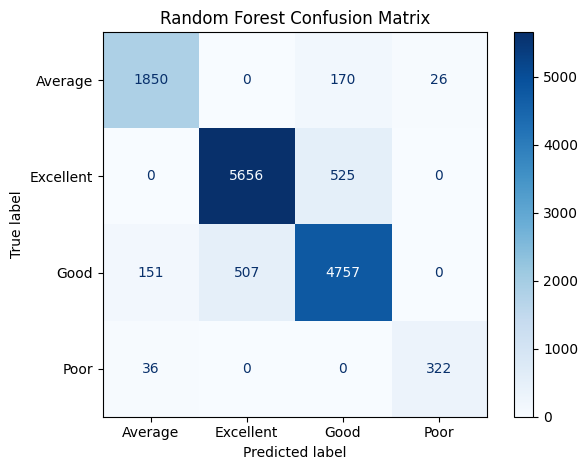

In [88]:
# Generate the confusion matrix
ml_random_forest_confusion_matrix = confusion_matrix(
    ml_y_test,
    ml_random_forest_predictions
)

# Display the confusion matrix
ml_random_forest_confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=ml_random_forest_confusion_matrix,
    display_labels=ml_label_encoder.classes_
)

ml_random_forest_confusion_matrix_display.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")

# Save the figure
# plt.savefig(
#     "../outputs/figures/random_forest_confusion_matrix.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.tight_layout()

plt.show()

**Observation**

The confusion matrix shows that the Random Forest model correctly classified the majority of internship records, with most predictions concentrated along the main diagonal. The model performed particularly well in identifying the **Excellent** and **Good** performance categories, with **5,656** and **4,757** correct predictions, respectively. It also achieved strong classification performance for the **Average** (**1,850**) and **Poor** (**322**) categories. Similar to the previous models, most misclassifications occurred between the **Excellent** and **Good** categories, indicating that these two performance levels have similar characteristics and are more difficult to distinguish. Compared with the Decision Tree model, the Random Forest model produced fewer classification errors and more correct predictions across most classes, resulting in improved overall classification performance. However, the Logistic Regression model still achieved the highest overall accuracy on this dataset.

### Model Comparison

The performance of all three machine learning models is compared using their testing accuracy. This comparison helps identify the model that provides the best predictive performance for the internship performance dataset.

In [89]:
# Create a comparison table for all models
ml_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        ml_logistic_accuracy,
        ml_decision_tree_accuracy,
        ml_random_forest_accuracy
    ]
})

# Convert accuracy into percentage
ml_model_comparison["Accuracy (%)"] = (
    ml_model_comparison["Accuracy"] * 100
).round(2)

# Display the comparison table
ml_model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.904071,90.41
1,Decision Tree,0.874643,87.46
2,Random Forest,0.898929,89.89


**Observation**

The comparison table summarizes the testing performance of all three machine learning models used in this project. **Logistic Regression** achieved the highest accuracy (**90.41%**), making it the best-performing model for predicting internship performance. **Random Forest** ranked second with an accuracy of **89.89%**, demonstrating strong classification performance while outperforming the Decision Tree model. **Decision Tree** achieved an accuracy of **87.46%**, providing reliable predictions but with comparatively lower performance than the other two models. Overall, the comparison indicates that Logistic Regression was the most effective model for this dataset, followed by Random Forest and Decision Tree.

### Conclusion

This project successfully developed and evaluated machine learning models to predict internship performance using a preprocessed internship dataset. The complete machine learning workflow included data preprocessing, feature selection, label encoding, one-hot encoding, train-test splitting, model training, prediction, and performance evaluation.

Three classification algorithms—**Logistic Regression**, **Decision Tree**, and **Random Forest**—were trained and evaluated using accuracy, classification reports, and confusion matrices. The experimental results showed that **Logistic Regression** achieved the highest testing accuracy (**90.41%**), followed by **Random Forest** (**89.89%**) and **Decision Tree** (**87.46%**). Although all three models demonstrated strong classification performance, Logistic Regression provided the most accurate and consistent predictions for this dataset.

Overall, this project demonstrates how different machine learning algorithms can be applied and compared to solve a real-world classification problem. The results highlight the importance of evaluating multiple models before selecting the most suitable one, as the best-performing algorithm depends on the characteristics of the dataset. This workflow provides a practical example of implementing supervised machine learning techniques using Python and the scikit-learn library for internship performance prediction.

## Model Saving and Prediction on New Data

After training and evaluating the machine learning models, the next step is to save the trained models and preprocessing objects so they can be reused without retraining. This allows the model to make predictions on new internship records in real-world applications.

### Import Required Library

In [2]:
import joblib

### Save Trained Models

After training and evaluating the machine learning models, they are saved to disk using the **Joblib** library. Saving the trained models allows them to be reused later for making predictions without retraining. This makes the workflow more efficient and suitable for deployment in real-world applications.

In [91]:
# Save Logistic Regression model
joblib.dump(
    ml_logistic_regression_model,
    "../models/logistic_regression_model.pkl"
)

# Save Decision Tree model
joblib.dump(
    ml_decision_tree_model,
    "../models/decision_tree_model.pkl"
)

# Save Random Forest model
joblib.dump(
    ml_random_forest_model,
    "../models/random_forest_model.pkl"
)

print("All trained models saved successfully.")

All trained models saved successfully.


**Observation**

All three trained machine learning models were successfully saved as **.pkl** files inside the **models** directory. These saved models can now be loaded later to make predictions on new internship records without repeating the training process.

### Save Preprocessing Objects

The preprocessing objects used during model training are also saved to ensure that new data is transformed in the same way as the training data. Saving these objects helps maintain consistency between the training and prediction phases.

In [92]:
# Save Label Encoder
joblib.dump(
    ml_label_encoder,
    "../models/label_encoder.pkl"
)

# Save One-Hot Encoder
joblib.dump(
    ml_onehot_encoder,
    "../models/onehot_encoder.pkl"
)

print("All preprocessing objects saved successfully.")

All preprocessing objects saved successfully.


**Observation**

The Label Encoder and One-Hot Encoder were successfully saved as preprocessing objects. These encoders will be reused to transform new internship records before they are passed to the trained machine learning models for prediction.

### Save Feature Columns

The feature names used during model training are saved separately. These feature columns are required during prediction to ensure that new internship records have the exact same structure as the training dataset. Saving the feature columns eliminates the need to recreate the training feature set after restarting the notebook.

In [117]:
# Save feature column names

joblib.dump(
    ml_X.columns.tolist(),
    "../models/feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.


**Observation**

The feature column names were successfully saved. These columns will be loaded during prediction to align new internship records with the exact structure used during model training.

### Load Saved Models and Preprocessing Objects

The previously saved machine learning models, preprocessing objects, and feature column names are loaded from disk using the **Joblib** library. These saved objects ensure that new internship records can be preprocessed, aligned, and predicted without retraining the models or recreating the training dataset.

In [6]:
# Load Logistic Regression model

ml_loaded_logistic_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

# Load Decision Tree model

ml_loaded_decision_tree_model = joblib.load(
    "../models/decision_tree_model.pkl"
)

# Load Random Forest model

ml_loaded_random_forest_model = joblib.load(
    "../models/random_forest_model.pkl"
)

# Load preprocessing objects

ml_loaded_label_encoder = joblib.load(
    "../models/label_encoder.pkl"
)

ml_loaded_onehot_encoder = joblib.load(
    "../models/onehot_encoder.pkl"
)

# Load feature column names

ml_feature_columns = joblib.load(
    "../models/feature_columns.pkl"
)

print("All models, preprocessing objects, and feature columns loaded successfully.")

All models, preprocessing objects, and feature columns loaded successfully.


**Observation**

All trained machine learning models, preprocessing objects, and feature column names were successfully loaded from the **models** directory. These loaded resources are now ready to preprocess, align, and predict the performance of new internship records without retraining the models or recreating the training feature set.

### Create New Internship Records

Multiple new internship records are created to simulate a real-world prediction scenario. These records contain the same input features that were used during model training. The trained machine learning model will predict the performance status of each unseen intern.

In [7]:
# Create new internship records

ml_new_intern = pd.DataFrame({

    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],

    "Age": [
        22, 23, 21, 24, 22,
        25, 23, 21, 24, 22
    ],

    "City": [
        "Lahore",
        "Karachi",
        "Faisalabad",
        "Islamabad",
        "Multan",
        "Peshawar",
        "Sialkot",
        "Rawalpindi",
        "Gujranwala",
        "Hyderabad"
    ],

    "Education": [
        "BS Computer Science",
        "BS Information Technology",
        "BS Software Engineering",
        "BS Data Science",
        "BS Computer Science",
        "BS Artificial Intelligence",
        "BS Information Technology",
        "BS Computer Science",
        "BS Data Science",
        "BS Software Engineering"
    ],

    "Institute": [
        "University of Central Punjab",
        "Government College University Faisalabad",
        "COMSATS University Islamabad",
        "Bahria University",
        "FAST National University",
        "University of Education",
        "National University of Sciences and Technology",
        "University of Engineering and Technology",
        "Superior University",
        "University of the Punjab"
    ],

    "Department": [
        "Backend Development",
        "Frontend Development",
        "Other Internships",
        "Graphic Design",
        "App Development",
        "Chatbot Development",
        "Backend Development",
        "Frontend Development",
        "Other Internships",
        "Graphic Design"
    ],

    "Internship_Track": [
        "PHP",
        "React",
        "Data Science",
        "Figma",
        "Flutter",
        "Generative AI",
        "Node.js",
        "Next.js",
        "Machine Learning",
        "Illustrator"
    ],

    "Internship_Duration_Weeks": [
        8, 8, 8, 8, 8,
        8, 8, 8, 8, 8
    ],

    "Weeks_Completed": [
        8, 8, 8, 8, 8,
        8, 8, 8, 8, 8
    ],

    "Attendance_Percentage": [
        97, 85, 65, 78, 99,
        72, 88, 95, 81, 90
    ],

    "Tasks_Assigned": [
        8, 8, 8, 8, 8,
        8, 8, 8, 8, 8
    ],

    "Tasks_Submitted": [
        8, 7, 4, 6, 8,
        5, 7, 8, 6, 8
    ],

    "Mentor_Interactions": [
        18, 12, 17, 10, 20,
        8, 13, 19, 11, 15
    ],

    "Feedback_Score": [
        4.9, 4.1, 3.2, 3.8, 5.0,
        3.5, 4.2, 4.8, 3.9, 4.4
    ]

})

ml_new_intern

,Gender,Age,City,Education,Institute,Department,Internship_Track,Internship_Duration_Weeks,Weeks_Completed,Attendance_Percentage,Tasks_Assigned,Tasks_Submitted,Mentor_Interactions,Feedback_Score
0,Male,22,Lahore,BS Computer Science,University of Central Punjab,Backend Development,PHP,8,8,97,8,8,18,4.9
1,Female,23,Karachi,BS Information Technology,Government College University Faisalabad,Frontend Development,React,8,8,85,8,7,12,4.1
2,Male,21,Faisalabad,BS Software Engineering,COMSATS University Islamabad,Other Internships,Data Science,8,8,65,8,4,17,3.2
3,Female,24,Islamabad,BS Data Science,Bahria University,Graphic Design,Figma,8,8,78,8,6,10,3.8
4,Male,22,Multan,BS Computer Science,FAST National University,App Development,Flutter,8,8,99,8,8,20,5.0
5,Female,25,Peshawar,BS Artificial Intelligence,University of Education,Chatbot Development,Generative AI,8,8,72,8,5,8,3.5
6,Male,23,Sialkot,BS Information Technology,National University of Sciences and Technology,Backend Development,Node.js,8,8,88,8,7,13,4.2
7,Female,21,Rawalpindi,BS Computer Science,University of Engineering and Technology,Frontend Development,Next.js,8,8,95,8,8,19,4.8
8,Male,24,Gujranwala,BS Data Science,Superior University,Other Internships,Machine Learning,8,8,81,8,6,11,3.9
9,Female,22,Hyderabad,BS Software Engineering,University of the Punjab,Graphic Design,Illustrator,8,8,90,8,8,15,4.4


**Observation**

Ten new internship records were successfully created using the same input features that were used during model training. These records represent unseen interns with different backgrounds, internship tracks, attendance, task completion, mentor interactions, and feedback scores. The dataset is now ready for preprocessing and batch performance prediction using the trained machine learning model.

### Encode the New Internship Records

The categorical features of the new internship records are transformed using the previously saved One-Hot Encoder. The numerical features remain unchanged. Both encoded categorical features and numerical features are then combined to create the final input dataset for batch prediction.

In [8]:
# Separate categorical and numerical features

ml_categorical_columns = [
    "Gender",
    "City",
    "Education",
    "Institute",
    "Department",
    "Internship_Track"
]

ml_numerical_columns = [
    "Age",
    "Internship_Duration_Weeks",
    "Weeks_Completed",
    "Attendance_Percentage",
    "Tasks_Assigned",
    "Tasks_Submitted",
    "Mentor_Interactions",
    "Feedback_Score"
]

# Encode categorical features

ml_encoded_categorical = ml_loaded_onehot_encoder.transform(
    ml_new_intern[ml_categorical_columns]
)

# Convert encoded features into a DataFrame

ml_encoded_categorical_df = pd.DataFrame(
    ml_encoded_categorical,
    columns=ml_loaded_onehot_encoder.get_feature_names_out(
        ml_categorical_columns
    )
)

# Reset indexes

ml_encoded_categorical_df.reset_index(drop=True, inplace=True)

ml_numerical_df = ml_new_intern[
    ml_numerical_columns
].reset_index(drop=True)

# Combine numerical and encoded categorical features

ml_new_intern_processed = pd.concat(
    [
        ml_numerical_df,
        ml_encoded_categorical_df.astype(int)
    ],
    axis=1
)

ml_new_intern_processed

,Age,Internship_Duration_Weeks,Weeks_Completed,Attendance_Percentage,Tasks_Assigned,Tasks_Submitted,Mentor_Interactions,Feedback_Score,Gender_Male,City_Bahawalpur,...,Internship_Track_Photoshop,Internship_Track_RASA,Internship_Track_React,Internship_Track_React Native,Internship_Track_Salesforce CRM,Internship_Track_Social Media,Internship_Track_Swift,Internship_Track_Video Editing,Internship_Track_Web 3.0,Internship_Track_WordPress
0,22,8,8,97,8,8,18,4.9,1,0,...,0,0,0,0,0,0,0,0,0,0
1,23,8,8,85,8,7,12,4.1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,21,8,8,65,8,4,17,3.2,1,0,...,0,0,0,0,0,0,0,0,0,0
3,24,8,8,78,8,6,10,3.8,0,0,...,0,0,0,0,0,0,0,0,0,0
4,22,8,8,99,8,8,20,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,25,8,8,72,8,5,8,3.5,0,0,...,0,0,0,0,0,0,0,0,0,0
6,23,8,8,88,8,7,13,4.2,1,0,...,0,0,0,0,0,0,0,0,0,0
7,21,8,8,95,8,8,19,4.8,0,0,...,0,0,0,0,0,0,0,0,0,0
8,24,8,8,81,8,6,11,3.9,1,0,...,0,0,0,0,0,0,0,0,0,0
9,22,8,8,90,8,8,15,4.4,0,0,...,0,0,0,0,0,0,0,0,0,0


**Observation**

All ten internship records were successfully transformed using the saved One-Hot Encoder. The categorical features were converted into numerical format, while the numerical features remained unchanged. The processed dataset is now ready to be aligned with the training feature set before generating batch predictions.

### Align the New Internship Records with Training Features

The processed internship records are aligned with the same feature columns that were used during model training. This step ensures that the prediction dataset has the exact same structure as the training dataset, preventing errors caused by missing or additional columns.

In [9]:
# Align the new internship records with training features

ml_new_intern_aligned = ml_new_intern_processed.reindex(
    columns=ml_feature_columns,
    fill_value=0
)

ml_new_intern_aligned

,Age,Internship_Duration_Weeks,Weeks_Completed,Attendance_Percentage,Tasks_Assigned,Tasks_Submitted,Mentor_Interactions,Feedback_Score,Gender_Male,City_Bahawalpur,...,Internship_Track_Photoshop,Internship_Track_RASA,Internship_Track_React,Internship_Track_React Native,Internship_Track_Salesforce CRM,Internship_Track_Social Media,Internship_Track_Swift,Internship_Track_Video Editing,Internship_Track_Web 3.0,Internship_Track_WordPress
0,22,8,8,97,8,8,18,4.9,1,0,...,0,0,0,0,0,0,0,0,0,0
1,23,8,8,85,8,7,12,4.1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,21,8,8,65,8,4,17,3.2,1,0,...,0,0,0,0,0,0,0,0,0,0
3,24,8,8,78,8,6,10,3.8,0,0,...,0,0,0,0,0,0,0,0,0,0
4,22,8,8,99,8,8,20,5.0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,25,8,8,72,8,5,8,3.5,0,0,...,0,0,0,0,0,0,0,0,0,0
6,23,8,8,88,8,7,13,4.2,1,0,...,0,0,0,0,0,0,0,0,0,0
7,21,8,8,95,8,8,19,4.8,0,0,...,0,0,0,0,0,0,0,0,0,0
8,24,8,8,81,8,6,11,3.9,1,0,...,0,0,0,0,0,0,0,0,0,0
9,22,8,8,90,8,8,15,4.4,0,0,...,0,0,0,0,0,0,0,0,0,0


**Observation**

All processed internship records were successfully aligned with the training feature set. Any missing feature columns were automatically filled with zeros, ensuring that the dataset has the same structure as the training data and is ready for batch prediction.

### Predict Internship Performance

The aligned internship records are passed to the trained Random Forest model to predict the performance status of each new intern. The predicted numerical labels are then converted back to their original performance categories using the saved Label Encoder. Finally, the predicted performance status is added to the internship records for easy interpretation.

In [10]:
# Predict internship performance

ml_predicted_labels = ml_loaded_random_forest_model.predict(
    ml_new_intern_aligned
)

# Convert encoded labels back to original categories

ml_predicted_performance = ml_loaded_label_encoder.inverse_transform(
    ml_predicted_labels
)

# Create final prediction results

ml_prediction_results = ml_new_intern.copy()

ml_prediction_results["Predicted_Performance_Status"] = (
    ml_predicted_performance
)

ml_prediction_results

,Gender,Age,City,Education,Institute,Department,Internship_Track,Internship_Duration_Weeks,Weeks_Completed,Attendance_Percentage,Tasks_Assigned,Tasks_Submitted,Mentor_Interactions,Feedback_Score,Predicted_Performance_Status
0,Male,22,Lahore,BS Computer Science,University of Central Punjab,Backend Development,PHP,8,8,97,8,8,18,4.9,Excellent
1,Female,23,Karachi,BS Information Technology,Government College University Faisalabad,Frontend Development,React,8,8,85,8,7,12,4.1,Good
2,Male,21,Faisalabad,BS Software Engineering,COMSATS University Islamabad,Other Internships,Data Science,8,8,65,8,4,17,3.2,Average
3,Female,24,Islamabad,BS Data Science,Bahria University,Graphic Design,Figma,8,8,78,8,6,10,3.8,Good
4,Male,22,Multan,BS Computer Science,FAST National University,App Development,Flutter,8,8,99,8,8,20,5.0,Excellent
5,Female,25,Peshawar,BS Artificial Intelligence,University of Education,Chatbot Development,Generative AI,8,8,72,8,5,8,3.5,Average
6,Male,23,Sialkot,BS Information Technology,National University of Sciences and Technology,Backend Development,Node.js,8,8,88,8,7,13,4.2,Excellent
7,Female,21,Rawalpindi,BS Computer Science,University of Engineering and Technology,Frontend Development,Next.js,8,8,95,8,8,19,4.8,Excellent
8,Male,24,Gujranwala,BS Data Science,Superior University,Other Internships,Machine Learning,8,8,81,8,6,11,3.9,Good
9,Female,22,Hyderabad,BS Software Engineering,University of the Punjab,Graphic Design,Illustrator,8,8,90,8,8,15,4.4,Excellent


**Observation**

The Random Forest model successfully predicted the performance status for all ten new internship records. The predicted results include four performance categories: **Excellent**, **Good**, and **Average**. The final prediction table combines the original internship information with the predicted performance status, allowing easy comparison between intern characteristics such as attendance percentage, task submission, mentor interactions, feedback score, and the model's predicted outcome. This demonstrates that the trained model can effectively classify the performance of unseen internship records using the learned patterns from the training dataset.

## Final Summary

This project successfully developed a machine learning solution for predicting internship performance using historical internship data. The complete workflow included data loading, exploratory data analysis (EDA), data preprocessing, feature encoding, feature engineering, model training, model evaluation, model saving, and prediction on new internship records.

Three classification algorithms—**Logistic Regression**, **Decision Tree**, and **Random Forest**—were trained and evaluated using standard performance metrics. Among these models, the **Random Forest Classifier** achieved the best overall performance and was selected as the final prediction model.

To build a reusable prediction pipeline, the trained machine learning models, preprocessing objects (Label Encoder and One-Hot Encoder), and feature column names were saved using the **Joblib** library. These saved objects were later loaded to preprocess and predict the performance of new internship records without retraining the models.

Finally, multiple unseen internship records were created, encoded, aligned with the original training feature structure, and successfully classified into their predicted performance categories. This project demonstrates a complete end-to-end machine learning workflow for internship performance prediction and provides a practical solution that can be extended to real-world internship management and decision-making systems.

**Observation**

The complete machine learning pipeline was successfully implemented, starting from data preprocessing and exploratory analysis to model training, evaluation, model persistence, and prediction. The Random Forest model produced reliable predictions for unseen internship records, demonstrating its effectiveness in predicting internship performance. The saved models and preprocessing objects also ensure that future predictions can be generated efficiently without repeating the training process.